## Data analysis- score distribution

In [1]:

import yaml

from final_exp_data_converter import convert_multiple_experiments
from main import SURVEY_VERSION, RAW_DATA, PROCESSED_XLSX_DATA, OLD_XLSX_DATA, MERGED_XLSX_DATA, DISTANCE_MATRIX, GROUP_SPACE_DATA, SUBJECT_WEIGHTS_DATA, INDIVIDUAL_GROUND_TRUTH, PLOTS_FOLDER, FA_FOLDER, LOPO_FOLDER, L2PO_FOLDER, STIMULI_NAMES, PARTICIPANTS_TO_EXCLUDE, TRANSFORMATIONS

with open('repo.yml', 'r') as file:
        repository_data = yaml.safe_load(file)

survey_version: str = repository_data[SURVEY_VERSION]
raw_data_paths: list[str] = repository_data[RAW_DATA]
processed_xlsx_data_path: str = repository_data[PROCESSED_XLSX_DATA]
old_xlsx_data_paths: list[str] = repository_data[OLD_XLSX_DATA]
merged_xlsx_data_path: str = repository_data[MERGED_XLSX_DATA]
distance_matrix_path: str = repository_data[DISTANCE_MATRIX]
group_space_data_path: str = repository_data[GROUP_SPACE_DATA]
subject_weights_data_path: str = repository_data[SUBJECT_WEIGHTS_DATA]
individual_ground_truth_path: str = repository_data[INDIVIDUAL_GROUND_TRUTH]
plots_folder_path: str = repository_data[PLOTS_FOLDER]
fa_folder_path: str = repository_data[FA_FOLDER]
lopo_folder_path: str = repository_data[LOPO_FOLDER]
l2po_folder_path: str = repository_data[L2PO_FOLDER]
stimuli_names: list[str] = repository_data[STIMULI_NAMES]
participants_to_exclude: list[str] = repository_data[PARTICIPANTS_TO_EXCLUDE]
transformations: dict[str, bool] = repository_data[TRANSFORMATIONS]

correct_participants= ['GFGzP', 'KWgkc', 'EXAMPLE', 'tMGNS', 'urJvc', 'yb3T2', '4FoNM', '5KB3V', 'CoQmx',
 'Cr1sTi', 'F5tXL', 'F8mDn', 'LR96S', 'PPjCX', 'VckNZ', 'hMHEK1', 'wohkw', '6GSd4',
 '8vDRG', 'Fjil72', 'Fyt7d', 'G4Egk', 'Gftw5', 'KoG5ii', 'M4t7k', 'O1pGR',
 'XhsN0o', 'kH4Dd', 'GHft8', 'WYuvqk', 'XPI3pA', 'h2yD5h', '7yqP3', 'G5XzoP',
 'NMy2s', 'Xd3foP9', 'gf5X', 'A5feTy', 'CVgs2', 'Dwf5T', 'ERqc8', 'G4dLl', 'Gr33d',
 'Hx7dO', 'Kgh4P3', 'SI3pa2', 'V9D5x', 'sop2d', '6k6gw', 'D7GcxxFf3', 'FWvvb87',
 'FcXX1', 'K34LOp', 'KLO33', 'Lso2g', 'Ou4tR', 'P67Dftt', 'SxRtt99', 'V11GHjjk',
 'VBr4ssd', 'XCv32m', 'XfdEE1', 'rt8Ye0r']

if survey_version in ['version_1', 'version_5', 'version_final']:
    emotions_to_use = ['Amused*', 'Angry*', 'Anxious*', 'Bored*', 'Calm*', 'Content*', 'Excited*', 'Fearful*',
                        'Happy*', 'Negative*', 'Positive*', 'Sad*']

    positive_emotions = ['Happy*', 'Positive*']
    negative_emotions = ['Angry*', 'Fearful*', 'Negative*', 'Sad*', 'Anxious*']

else:
    emotions_to_use = ['Amused*', 'Angry*', 'Bored*', 'Calm*', 'Content*', 'Disgust*', 'Excited*', 'Fearful*',
                        'Happy*', 'Negative*', 'Positive*', 'Sad*']

In [8]:

import pandas as pd

path = 'preprocessed_data_standard_normalization.csv'
# Carica i dati
data = pd.read_csv(path)

### Generate distribution per participant

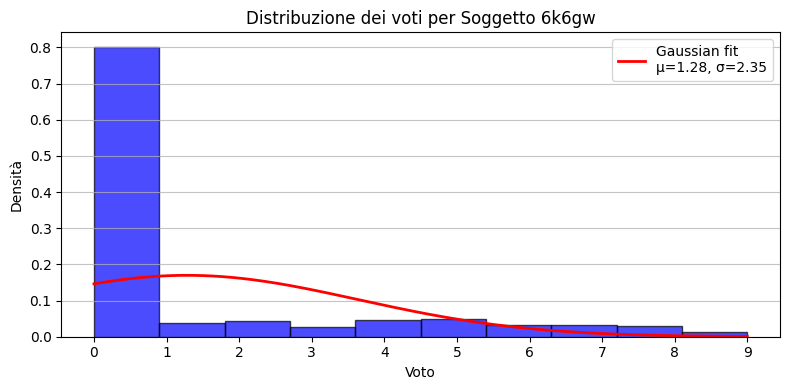

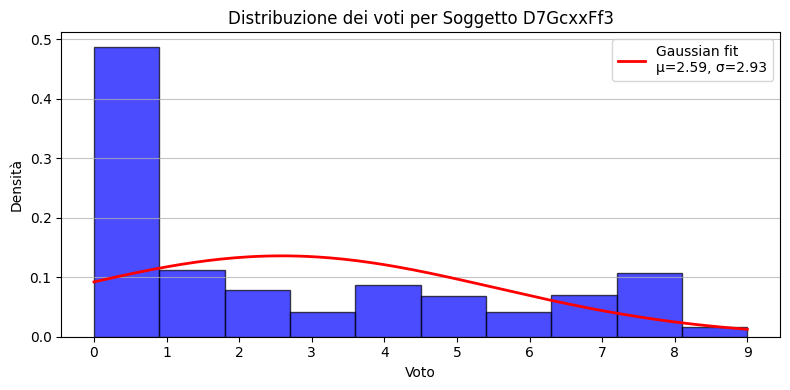

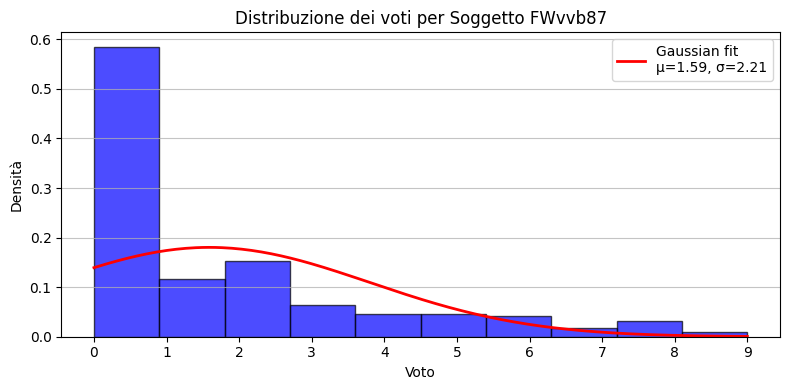

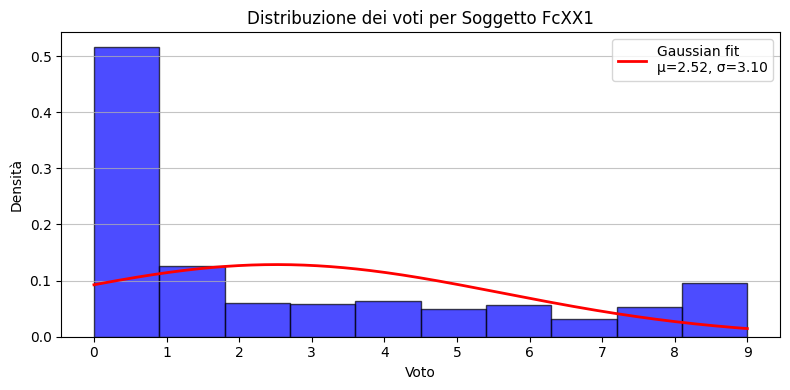

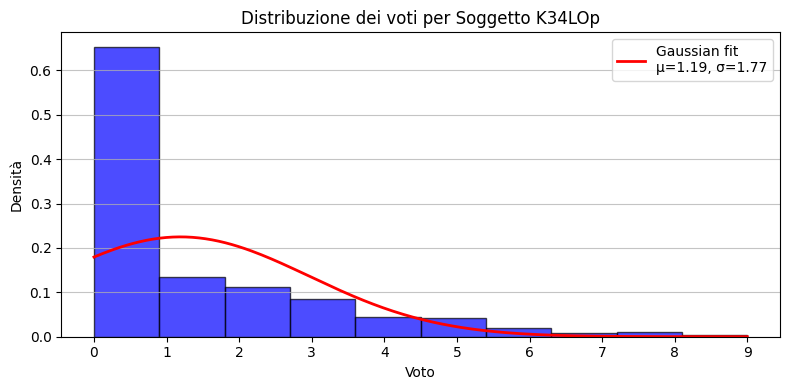

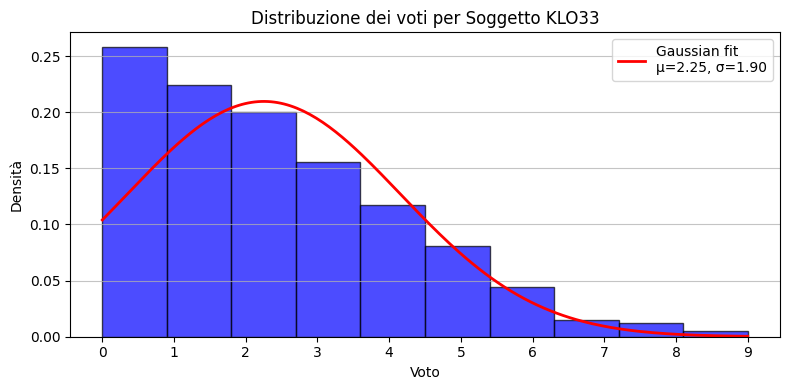

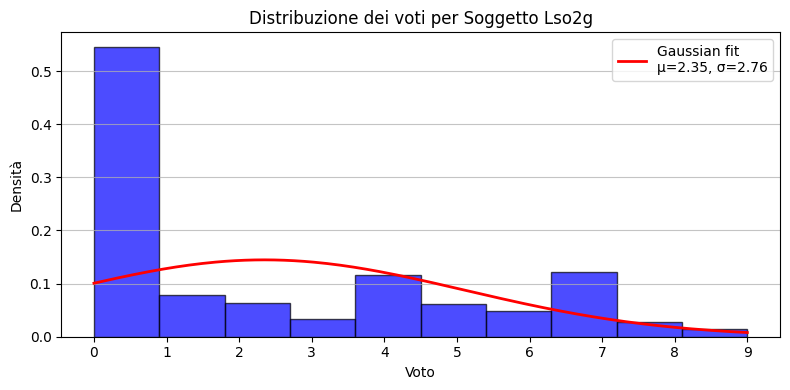

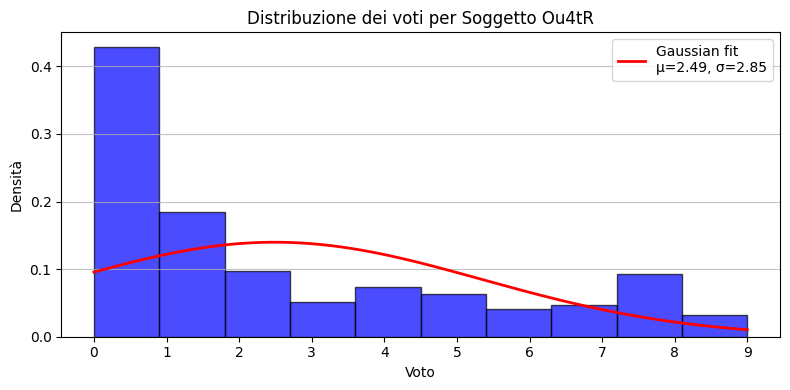

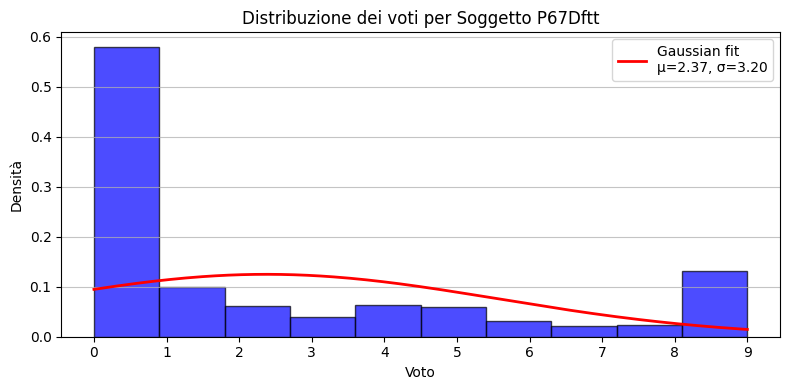

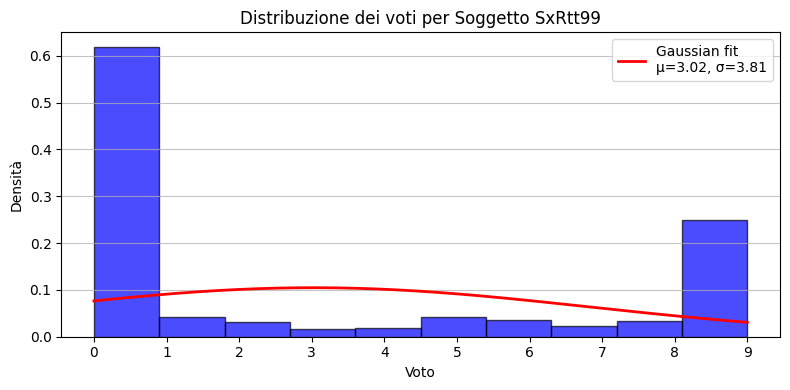

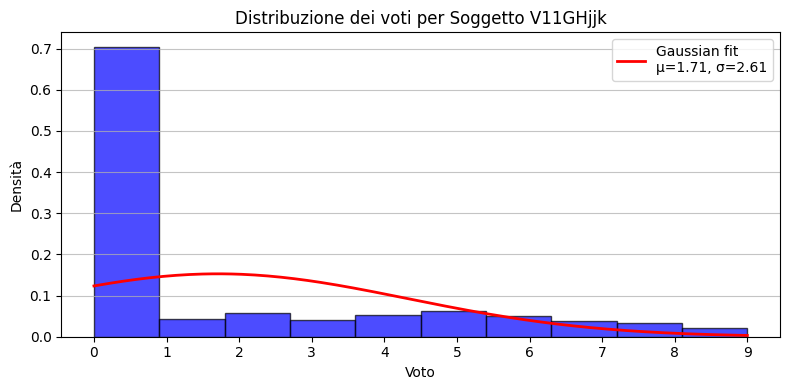

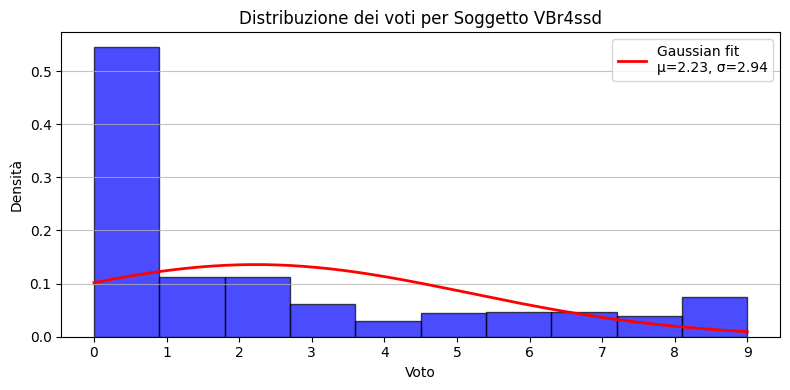

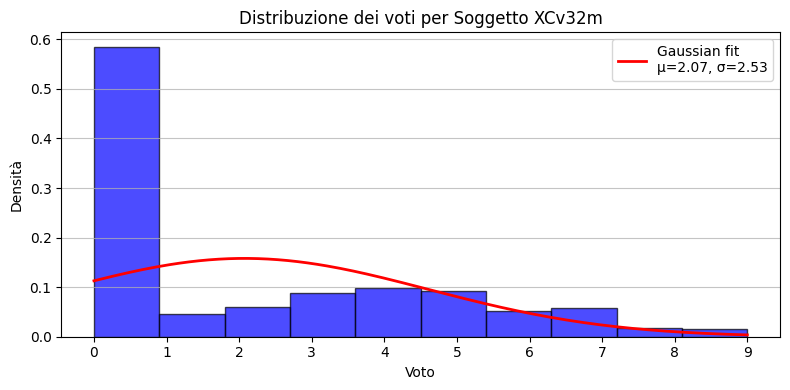

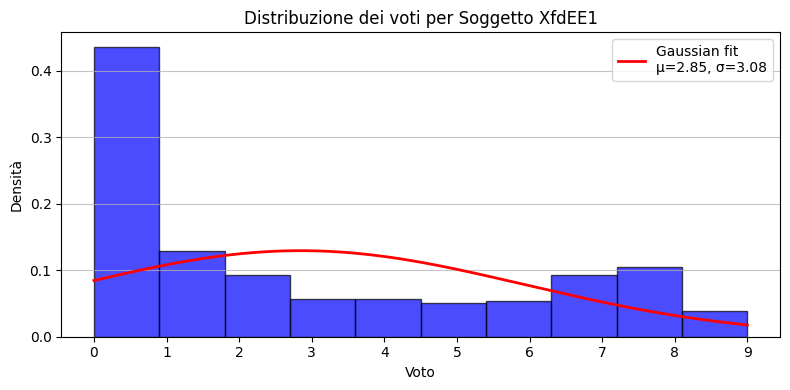

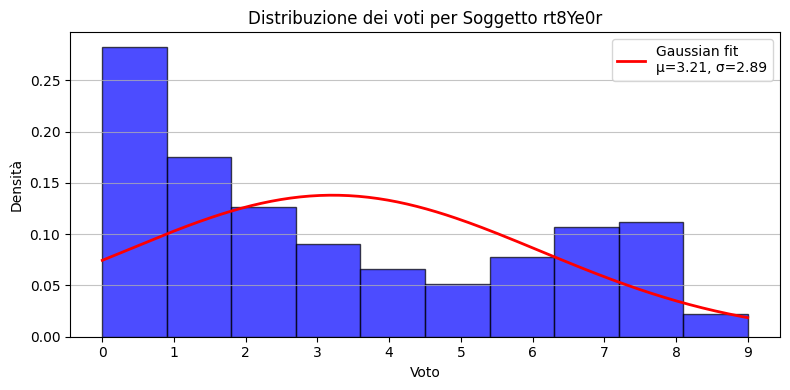

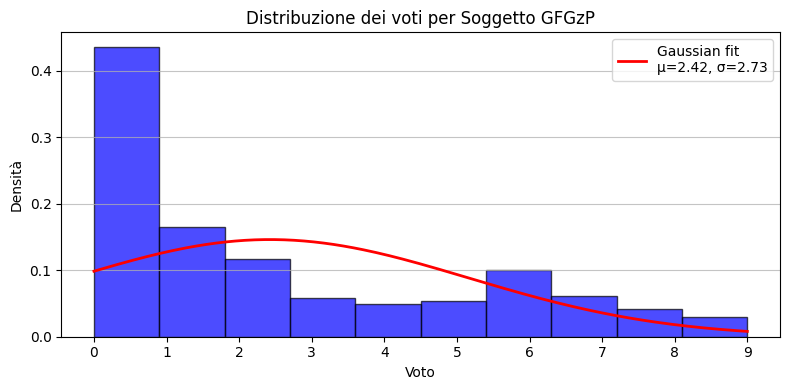

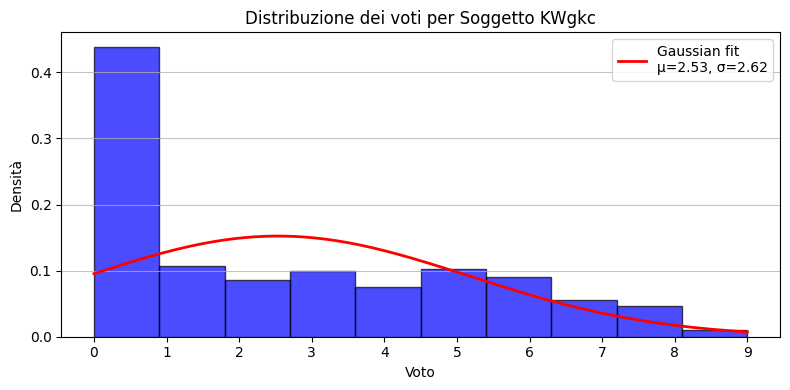

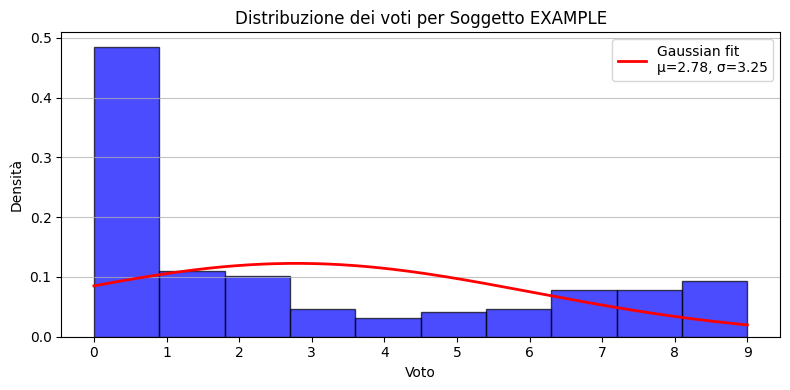

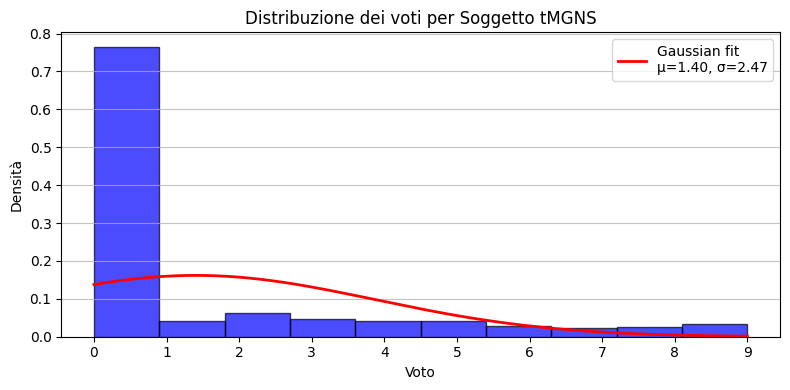

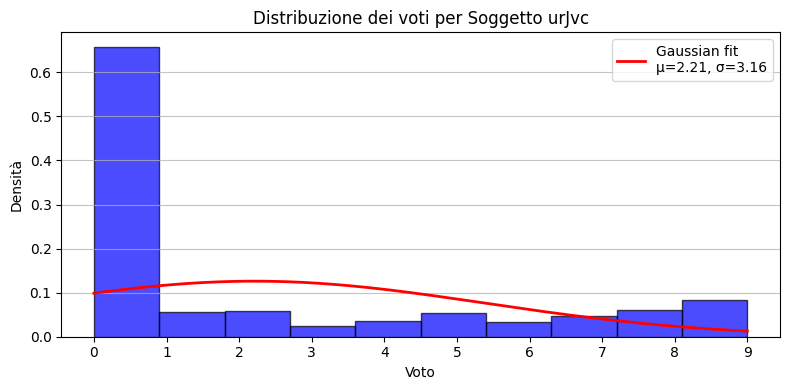

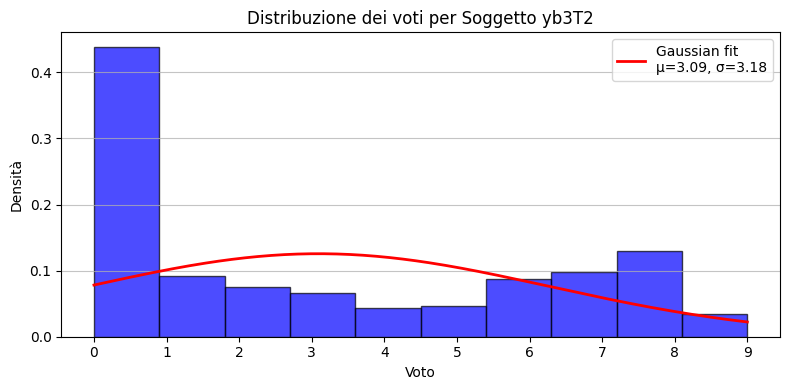

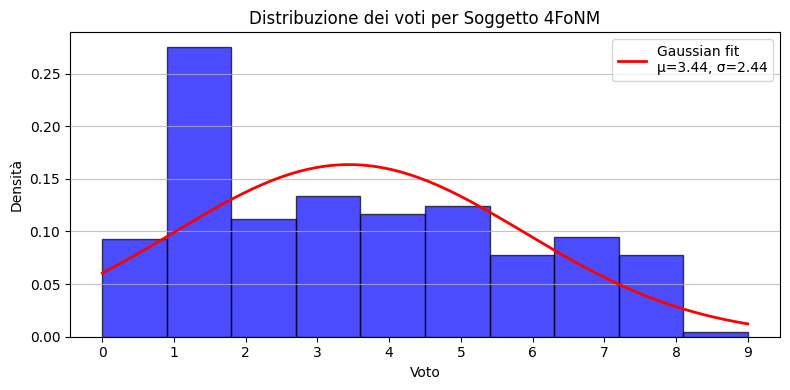

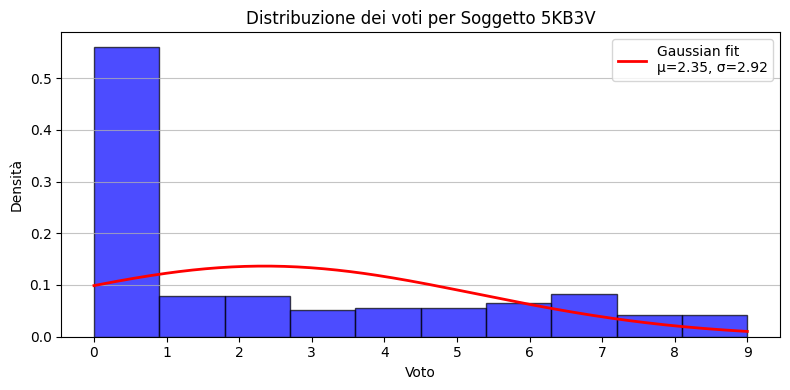

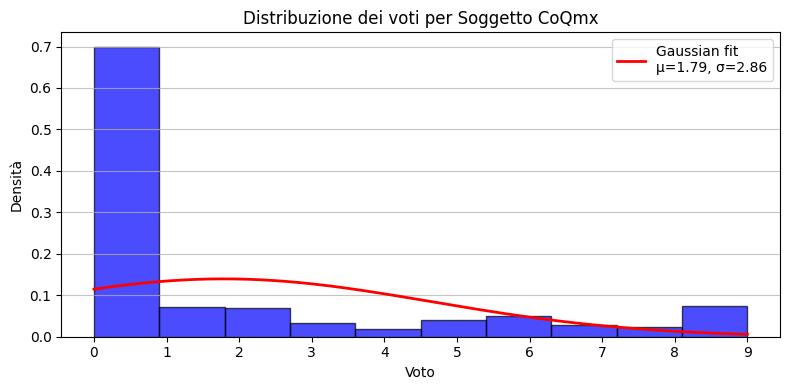

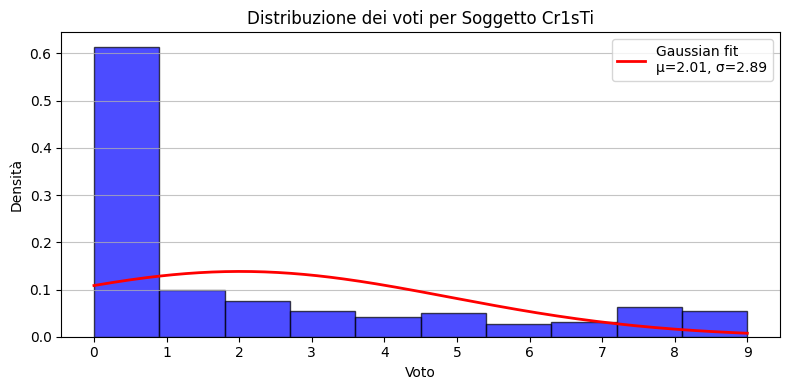

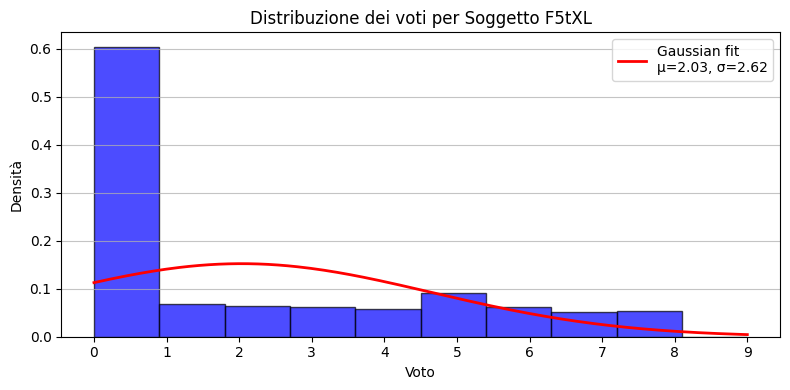

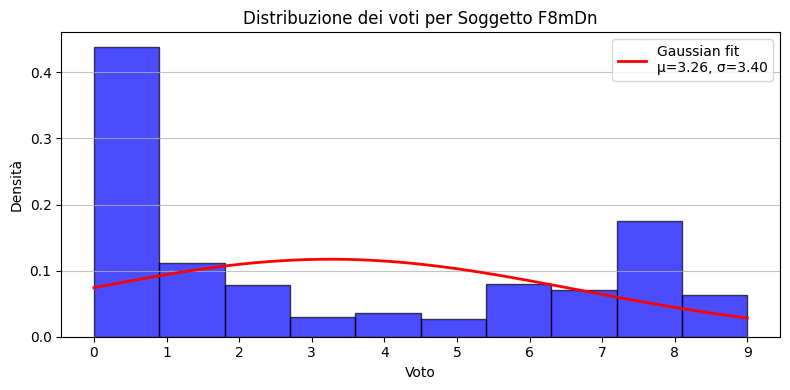

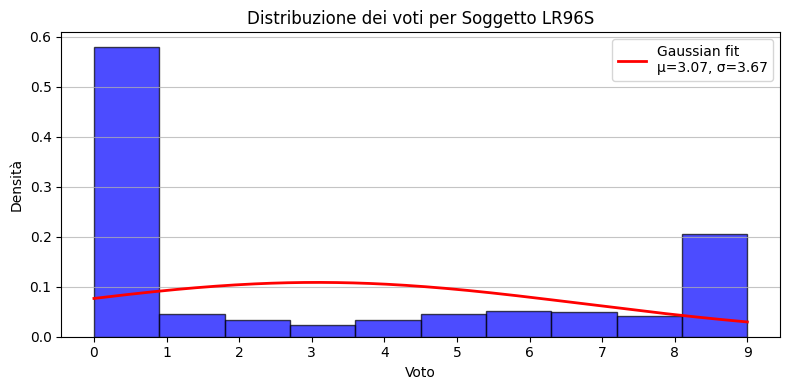

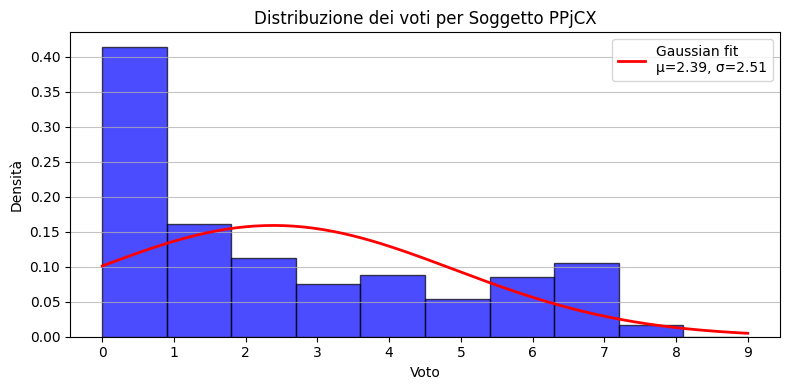

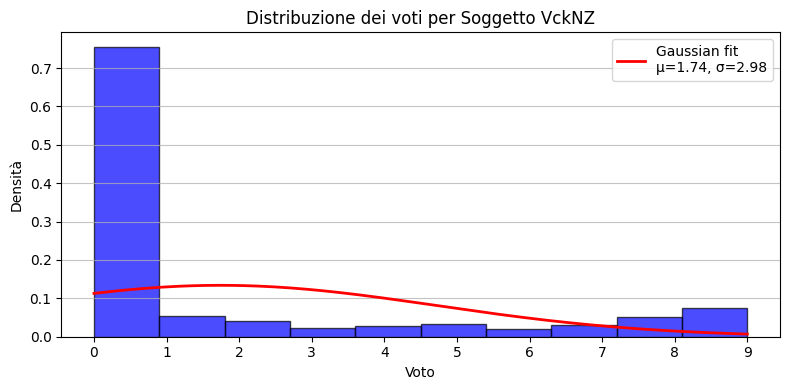

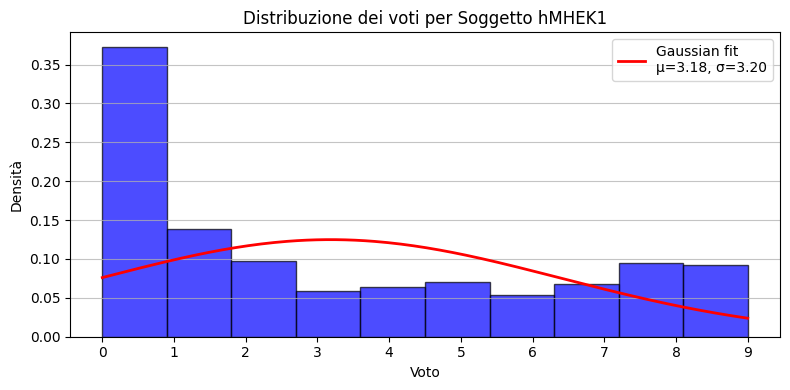

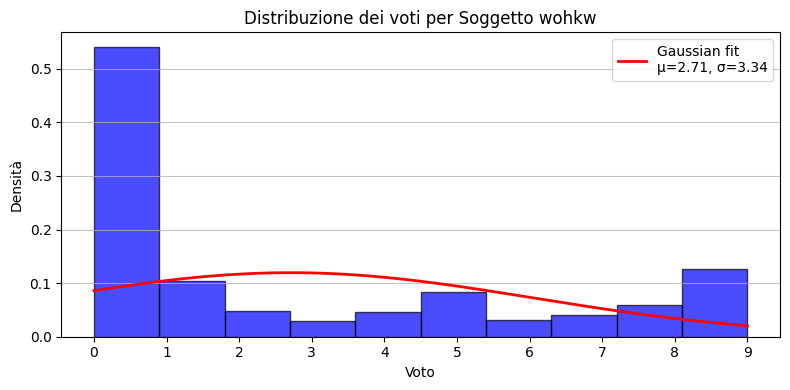

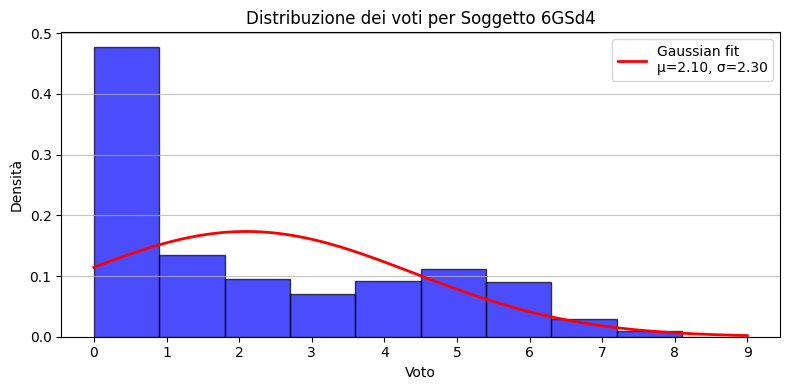

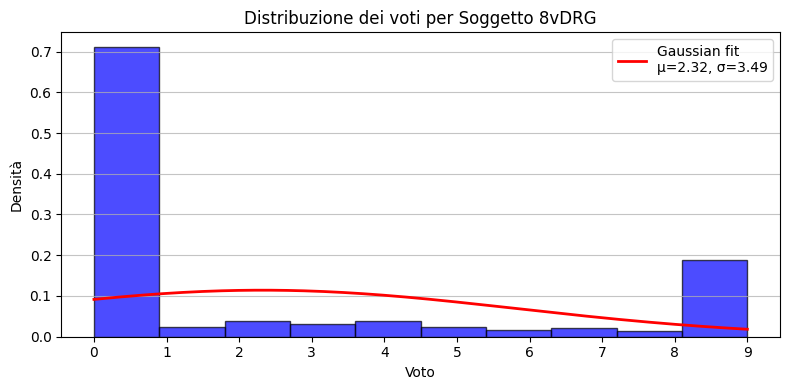

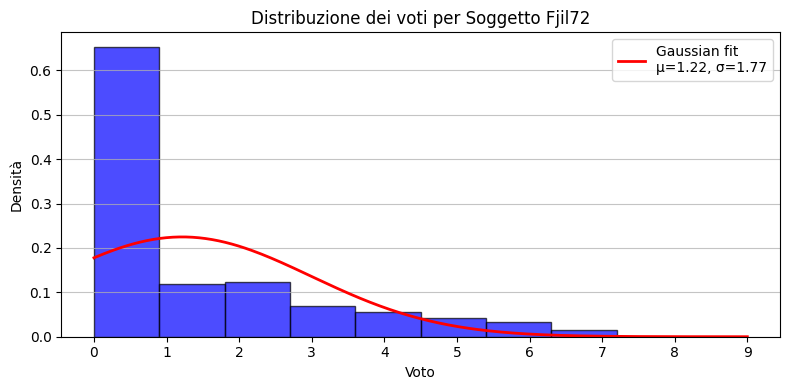

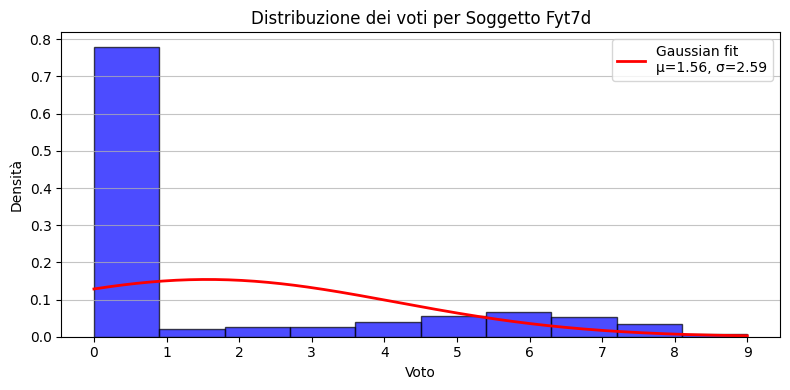

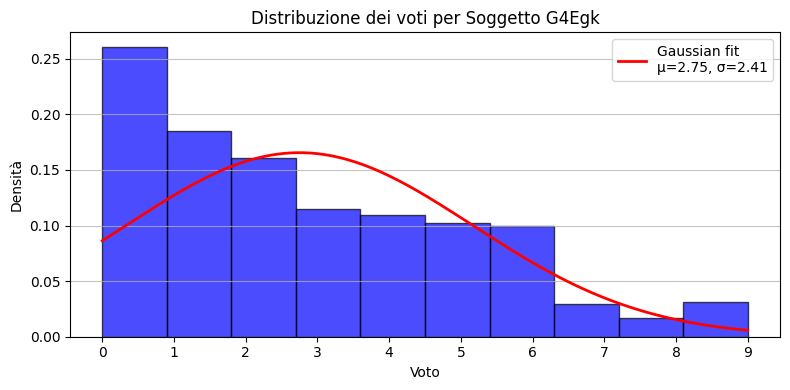

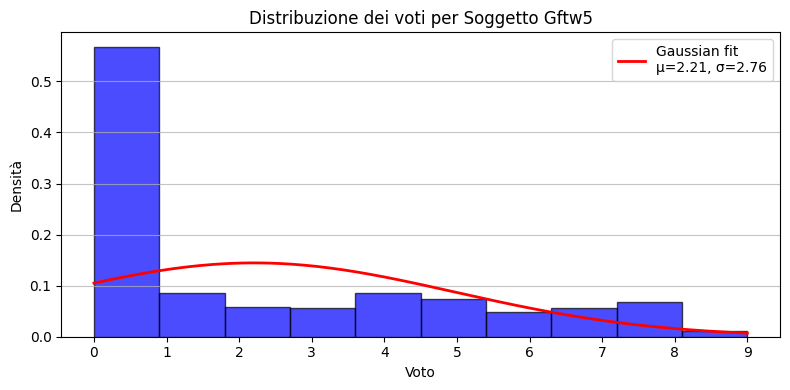

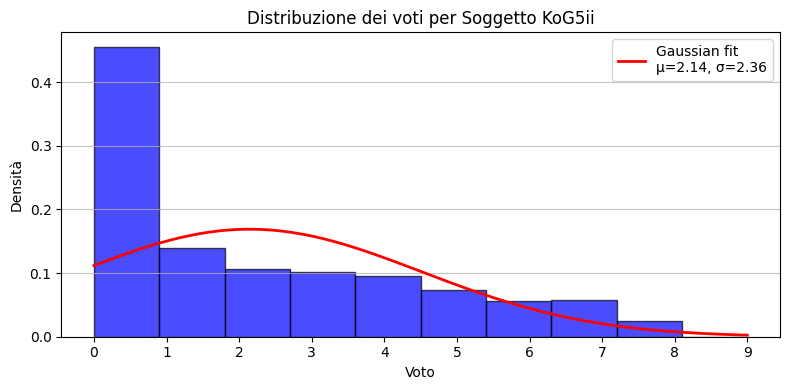

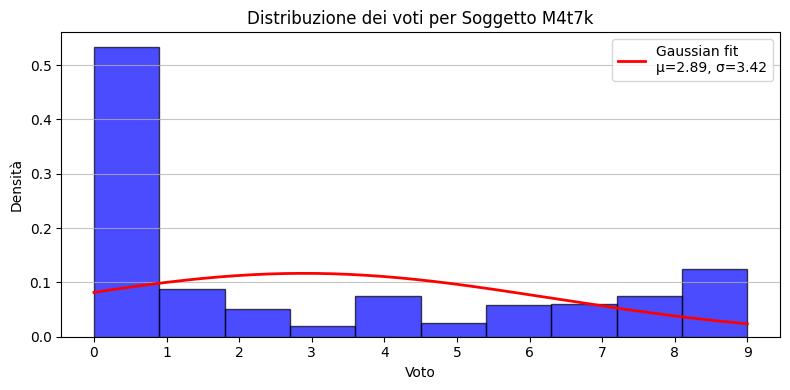

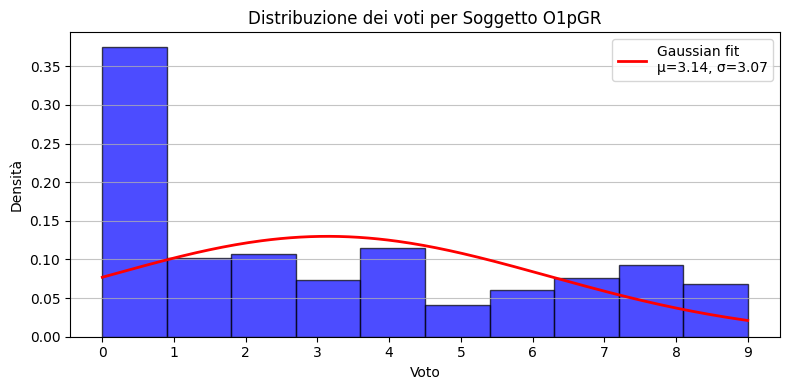

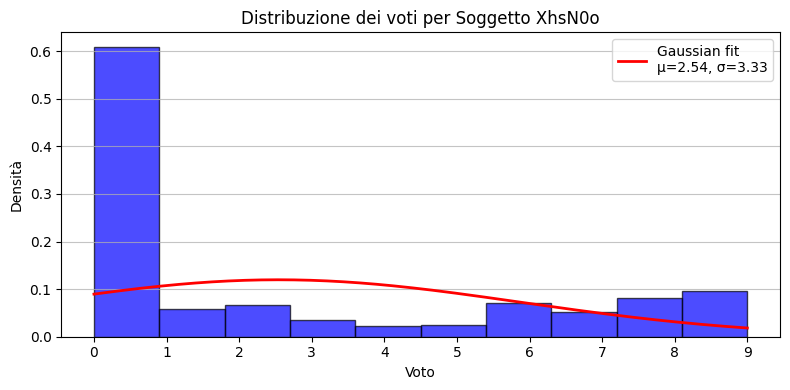

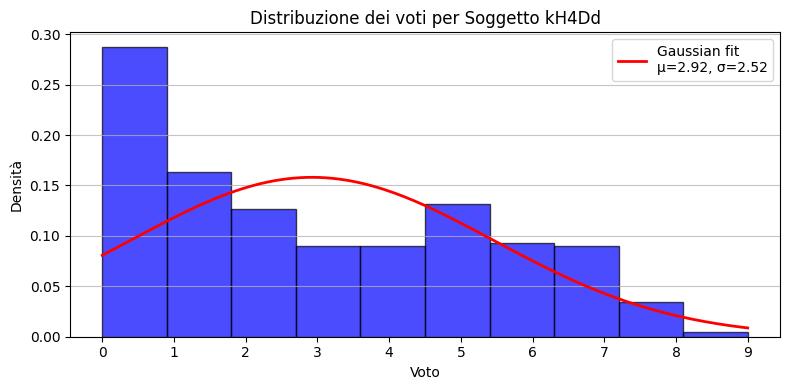

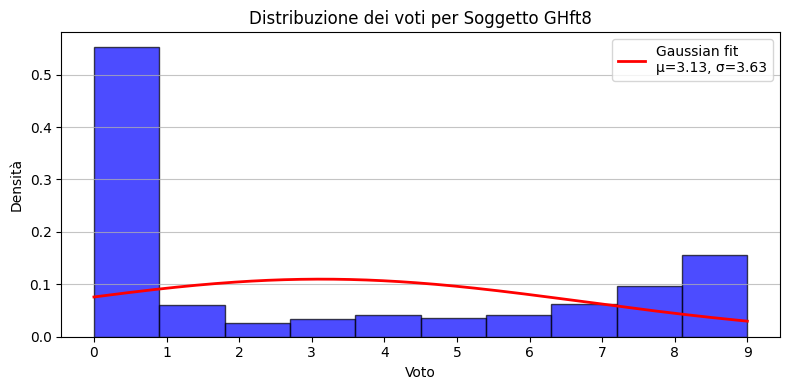

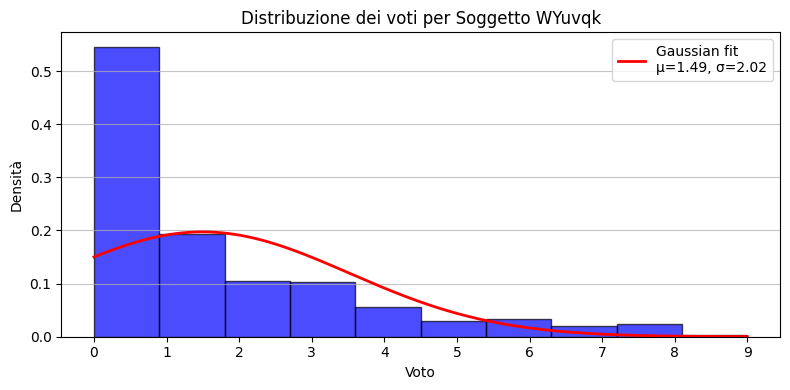

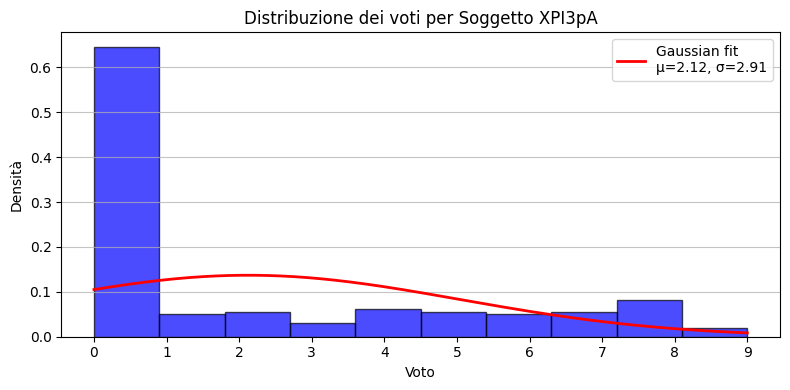

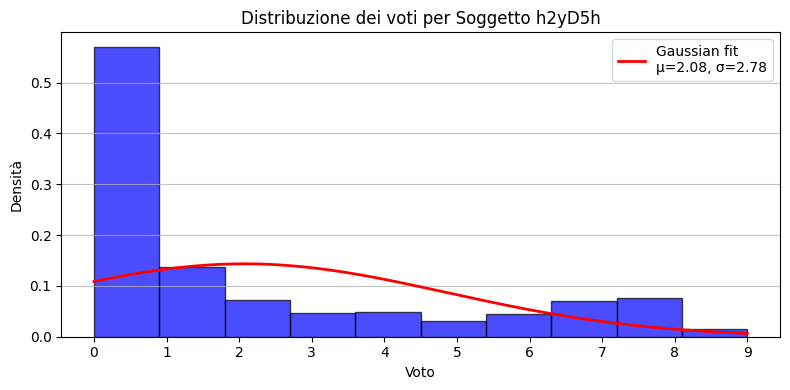

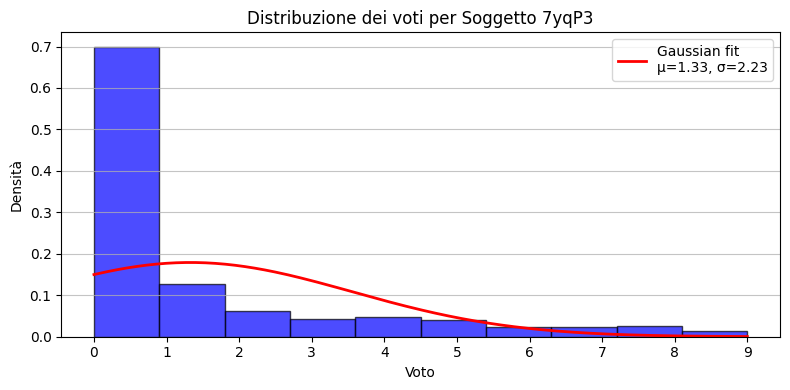

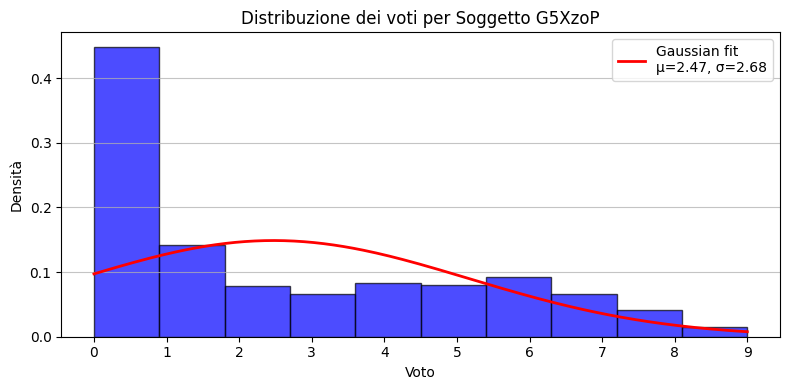

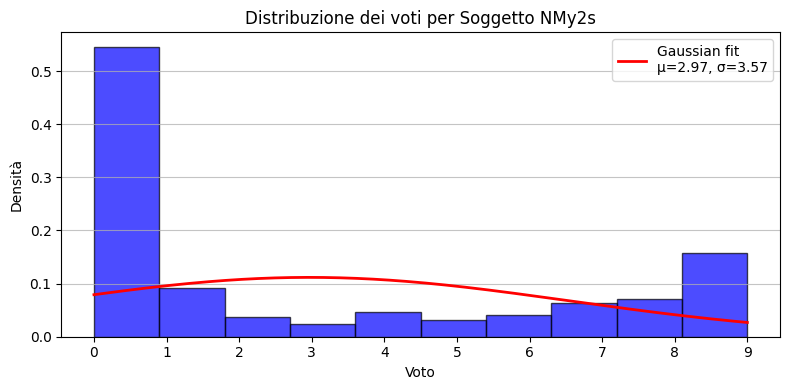

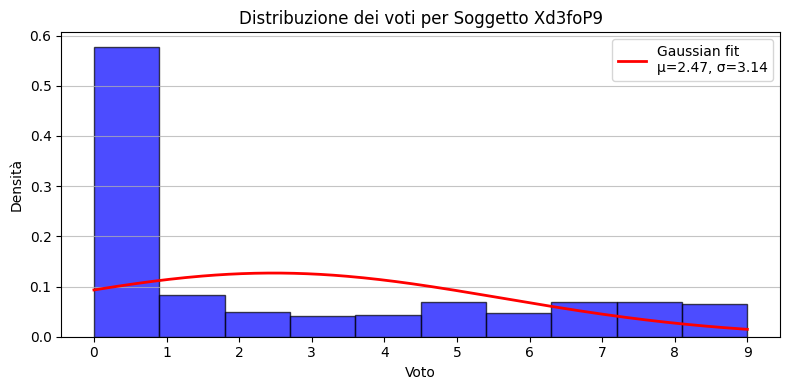

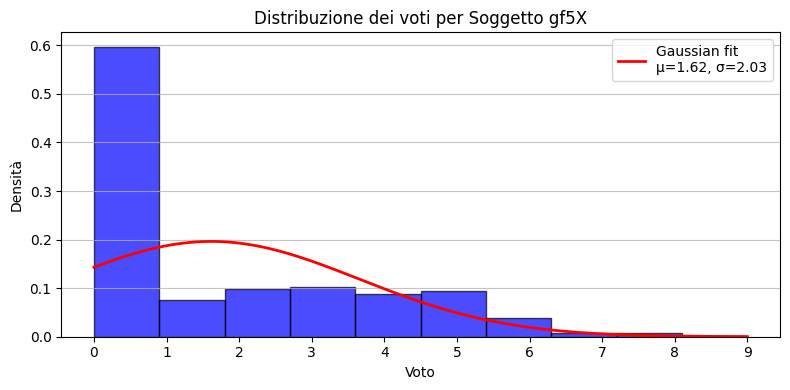

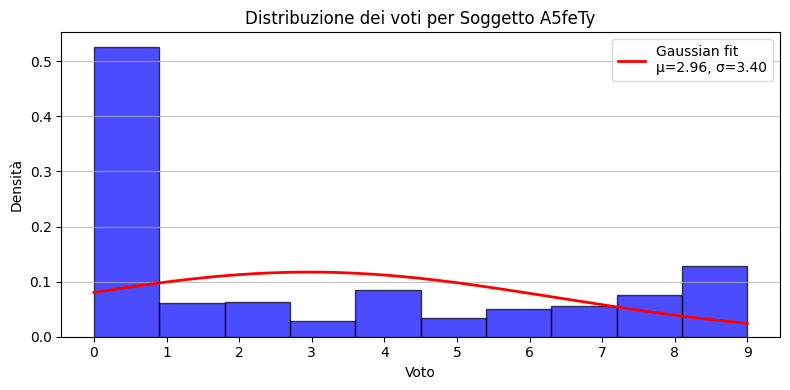

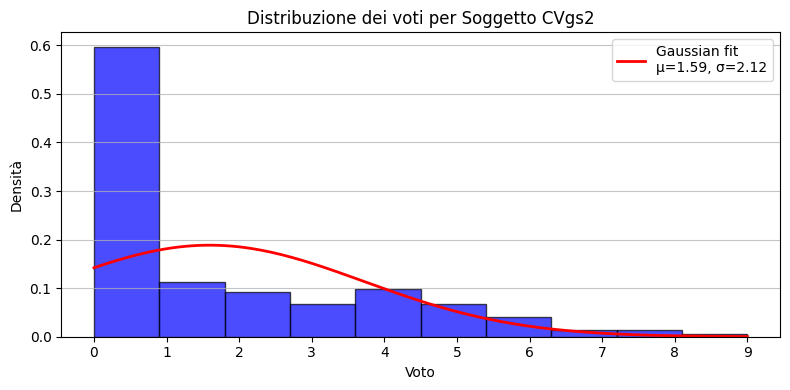

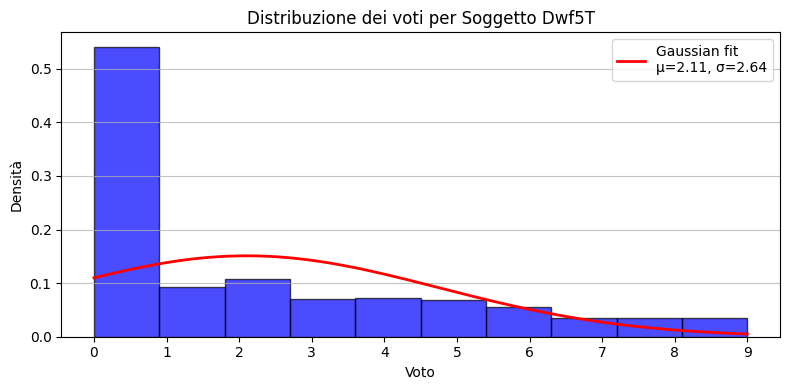

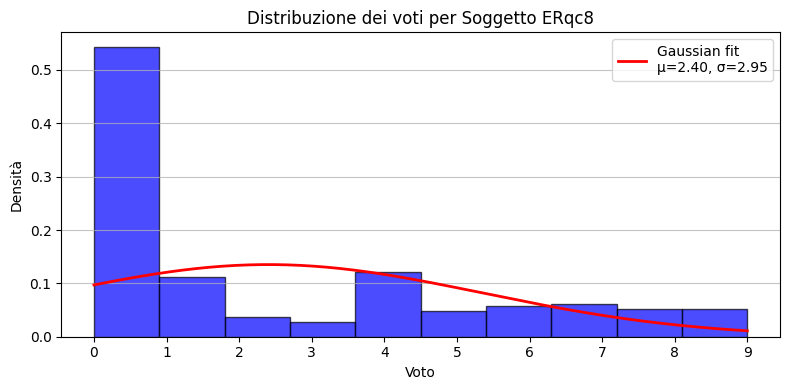

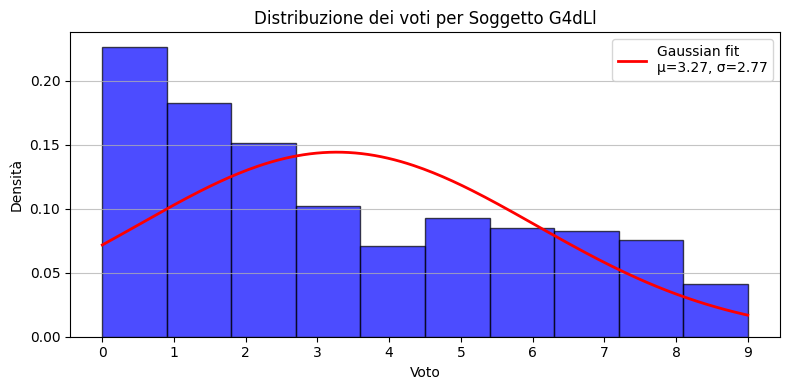

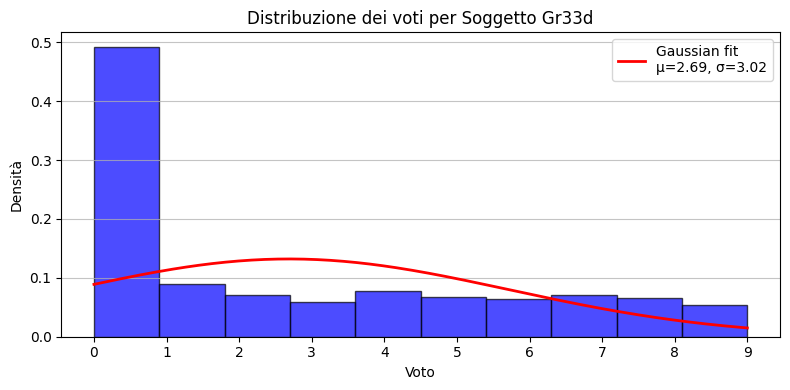

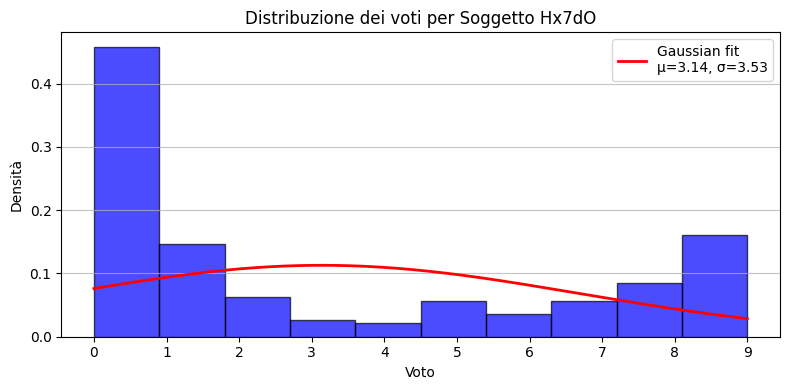

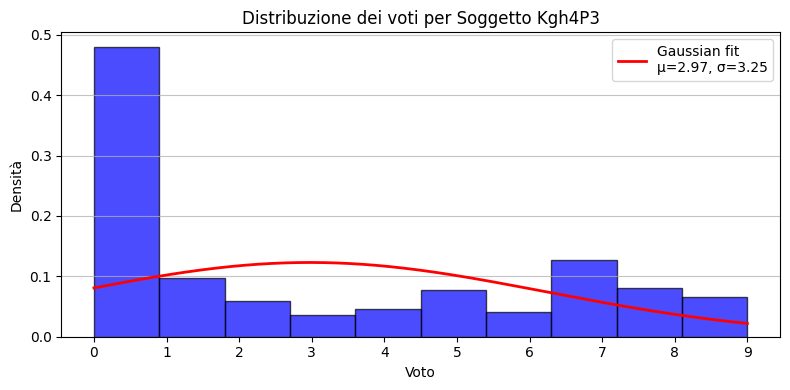

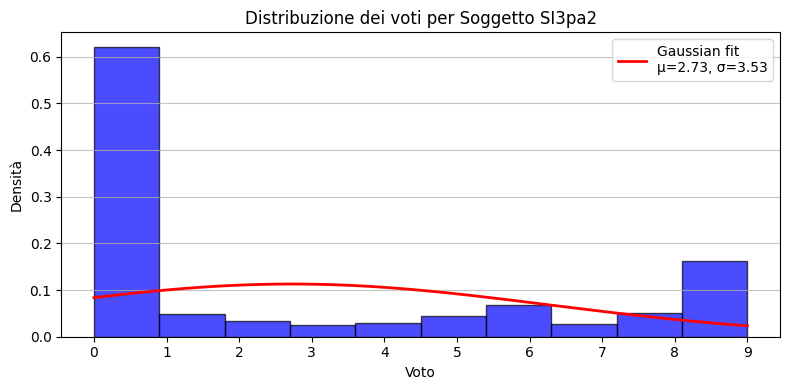

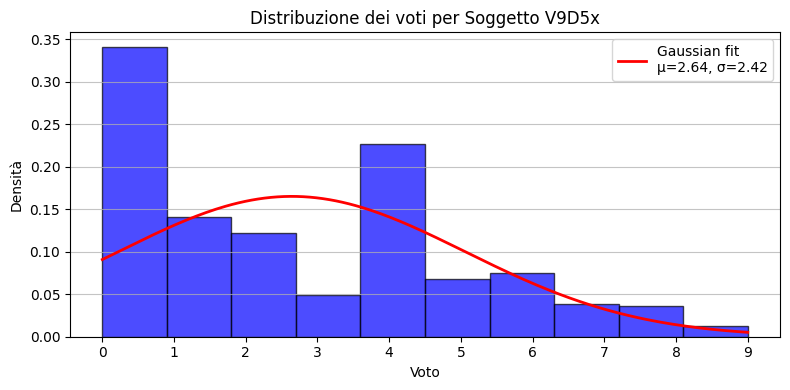

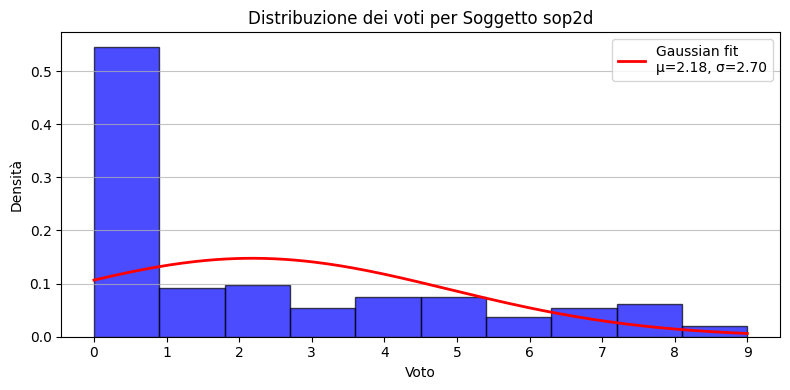

In [5]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


# Assicurati che emotions_to_use sia una lista di colonne esistente
# es. emotions_to_use = ['Happy_normalized', 'Sad_normalized', ...]
# Se l'hai definita altrove nel notebook, rimuovi la linea seguente
# emotions_to_use = [...]

# Seleziona solo le colonne interessate
data = data[['Participant'] + emotions_to_use]

for participant in data['Participant'].unique():
    # tutte le righe del partecipante e solo le colonne emozioni
    emotion_df = data.loc[data['Participant'] == participant, emotions_to_use]
    # appiattisci in un vettore 1D di valori numerici
    values = emotion_df.to_numpy().ravel()
    # rimuovi eventuali NaN
    values = values[~np.isnan(values)]

    if values.size == 0:
        print(f"{participant}: nessun valore disponibile")
        continue

    mu = values.mean()
    sigma = values.std(ddof=0)

    plt.figure(figsize=(8, 4))
    # usa density=True se vuoi confrontare la pdf (y in densità)
    counts, bins, patches = plt.hist(values, bins=10, range=(0, 9), alpha=0.7,
                                    color='blue', edgecolor='black', density=True)

    x = np.linspace(0, 9, 200)
    if sigma > 0:
        pdf = norm.pdf(x, mu, sigma)
        plt.plot(x, pdf, 'r-', linewidth=2, label=f'Gaussian fit\nμ={mu:.2f}, σ={sigma:.2f}')
    else:
        plt.axvline(mu, color='r', linestyle='--', label=f'Constant value μ={mu:.2f}')

    plt.title(f'Distribuzione dei voti per Soggetto {participant}')
    plt.xlabel('Voto')
    plt.ylabel('Densità')
    plt.xticks(range(0, 10))
    plt.legend()
    plt.grid(axis='y', alpha=0.75)
    plt.tight_layout()
    # Assicurati che la cartella esista prima di salvare
    import os
    out_dir = 'img/participant_analysis'
    os.makedirs(out_dir, exist_ok=True)
    # Salva la figura prima di show() per evitare backend che la svuotano
    plt.savefig(os.path.join(out_dir, f'{participant}_histogram.png'), bbox_inches='tight', dpi=150)
    plt.show()
    plt.close()

## Samples

*Outliers:*
<img src='img/participant_analysis/LR96S_histogram.png'>
<img src='img/participant_analysis/SxRtt99_histogram.png'>

**Extreme Response Bias**: la loro distribuzione non è semplicemente "piatta" (platicurtica), è fortemente bimodale. Hanno risposto quasi sempre 0 (circa il 60% delle volte) oppure 9 (il 20-25% delle volte), ignorando quasi del tutto i valori centrali.


*best reconstructed*
<img src='img/participant_analysis/V9D5x_histogram.png'>

## skewness e kurtosis
sono indicatori statistici fondamentali usati per descrivere la forma di una distribuzione di dati e misurare quanto questa si discosti da una perfetta distribuzione normale (a campana)

1. Skewness (Asimmetria)
La skewness misura la simmetria di una distribuzione rispetto alla sua media. Indica se i dati sono sbilanciati verso destra o verso sinistra. 

- *Simmetrica (Skewness)*: La curva è perfettamente bilanciata. Media, mediana e moda coincidono.
- *Asimmetria Positiva (Skewness > 0)*: La "coda" della distribuzione è più lunga verso destra (valori alti). La media è maggiore della mediana.
- *Asimmetria Negativa (Skewness < 0)*: La "coda" è più lunga verso sinistra (valori bassi). La media è minore della mediana. 


2. Kurtosis (Curtosi)
La kurtosis misura il livello di appiattimento o appuntimento della distribuzione rispetto alla normale, e indica quanto i dati sono concentrati al centro o pesanti sulle code (presenza di outlier). 

- *Mesocurtica (Kurtosis)*: La distribuzione ha la stessa forma di una normale. L'eccesso di curtosi è zero.
- *Leptocurtica (Kurtosis > 3 / Eccesso > 0)*: Distribuzione più appuntita con code pesanti. Significa che c'è un'alta concentrazione di dati attorno alla media, ma anche molti valori anomali (outlier) estremi.
- *Platicurtica (Kurtosis < 3 / Eccesso < 0)*: Distribuzione più piatta e schiacciata. I dati sono più dispersi e le code sono più leggere (meno outlier). 

In [14]:
# calcola skewness e kurtosis per ogni partecipante e salva in un dataframe
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis

# Lista per accumulare i dati (approccio moderno e veloce, compatibile con Pandas 2.0+)
rows = []

for participant in data['Participant'].unique():
    emotion_df = data.loc[data['Participant'] == participant, emotions_to_use]
    values = emotion_df.to_numpy().ravel()
    values = values[~np.isnan(values)]

    # Inizializzazione delle variabili per i casi senza dati
    skewness = np.nan
    kurt = np.nan
    skewness_type = 'Senza dati'
    kurtosis_type = 'Senza dati'

    if values.size > 0:
        skewness = skew(values)
        # fisher=True di default calcola l'eccesso di curtosi (Normale = 0)
        kurt = kurtosis(values, fisher=True) 
        
        # 1. Classificazione Skewness (Asimmetria)
        if abs(skewness) < 0.5:
            skewness_type = 'Simmetrica'
        elif skewness >= 0.5:
            skewness_type = 'Asimmetria Positiva (Coda a destra)'
        else:
            skewness_type = 'Asimmetria Negativa (Coda a sinistra)'
            
        # 2. Classificazione Kurtosis (basata su Excess Kurtosis: Normale = 0)
        # Usiamo +/- 1 come soglia indicativa per scostamenti moderati/forti
        if abs(kurt) <= 1:
            kurtosis_type = 'Mesocurtica (Normale)'
        elif kurt > 1:
            kurtosis_type = 'Leptocurtica (Picco alto / Code pesanti)'
        else: # kurt < -1
            kurtosis_type = 'Platicurtica (Piatta / Code leggere)'

    # Aggiungiamo i risultati alla lista
    rows.append({
        'Participant': participant,
        'Skewness': skewness,
        'Kurtosis': kurt,
        'Skewness_Analysis': skewness_type,
        'Kurtosis_Analysis': kurtosis_type
    })

# Creazione del DataFrame finale da tutte le righe accumulate
skew_kurtosis_df = pd.DataFrame(rows)

  Participant  Skewness  Kurtosis                    Skewness_Analysis  \
0       6k6gw  1.752484  1.816972  Asimmetria Positiva (Coda a destra)   
1   D7GcxxFf3  0.758953 -0.919810  Asimmetria Positiva (Coda a destra)   
2     FWvvb87  1.485807  1.345094  Asimmetria Positiva (Coda a destra)   
3       FcXX1  0.961749 -0.532335  Asimmetria Positiva (Coda a destra)   
4      K34LOp  1.701622  2.499060  Asimmetria Positiva (Coda a destra)   
5       KLO33  0.811411  0.071426  Asimmetria Positiva (Coda a destra)   
6       Lso2g  0.766234 -0.893231  Asimmetria Positiva (Coda a destra)   
7       Ou4tR  0.928771 -0.526297  Asimmetria Positiva (Coda a destra)   
8     P67Dftt  1.097392 -0.289658  Asimmetria Positiva (Coda a destra)   
9     SxRtt99  0.695205 -1.322047  Asimmetria Positiva (Coda a destra)   

                          Kurtosis_Analysis  
0  Leptocurtica (Picco alto / Code pesanti)  
1                     Mesocurtica (Normale)  
2  Leptocurtica (Picco alto / Code pesanti)  
3

In [15]:
# salva il DataFrame in un file CSV
skew_kurtosis_df.to_csv('participant_skewness_kurtosis_analysis.csv', index=False)


### selezionare solo i partecipanti 'Leptocurtica (Picco alto / Code pesanti)' che dovrebbero essere outliers

In [18]:
outliers_kurtosis = skew_kurtosis_df[skew_kurtosis_df['Kurtosis_Analysis'] == 'Platicurtica (Piatta / Code leggere)']
# ordina per kurtosis decrescente 

outliers_kurtosis = outliers_kurtosis.sort_values(by='Kurtosis', ascending=True)
print(f"Rilevati {len(outliers_kurtosis)} partecipanti con distribuzioni platicurtiche:")   
for row in outliers_kurtosis.itertuples():
    print(f"Partecipante: {row.Participant}")
    print(f"  Skewness: {row.Skewness:.4f} -> {row.Skewness_Analysis}")
    print(f"  Kurtosis: {row.Kurtosis:.4f} -> {row.Kurtosis_Analysis}")
    print("-" * 50)



Rilevati 18 partecipanti con distribuzioni platicurtiche:
Partecipante: F8mDn
  Skewness: 0.4612 -> Simmetrica
  Kurtosis: -1.4888 -> Platicurtica (Piatta / Code leggere)
--------------------------------------------------
Partecipante: GHft8
  Skewness: 0.5784 -> Asimmetria Positiva (Coda a destra)
  Kurtosis: -1.4019 -> Platicurtica (Piatta / Code leggere)
--------------------------------------------------
Partecipante: yb3T2
  Skewness: 0.4892 -> Simmetrica
  Kurtosis: -1.3637 -> Platicurtica (Piatta / Code leggere)
--------------------------------------------------
Partecipante: LR96S
  Skewness: 0.6388 -> Asimmetria Positiva (Coda a destra)
  Kurtosis: -1.3241 -> Platicurtica (Piatta / Code leggere)
--------------------------------------------------
Partecipante: SxRtt99
  Skewness: 0.6952 -> Asimmetria Positiva (Coda a destra)
  Kurtosis: -1.3220 -> Platicurtica (Piatta / Code leggere)
--------------------------------------------------
Partecipante: Hx7dO
  Skewness: 0.6336 -> Asi

In [25]:
import numpy as np
import pandas as pd

all_participants = list(data['Participant'].unique())

# Lista dei 18 platicurtici estratti dalla tua analisi
platicurtici = [
    'F8mDn', 'GHft8', 'yb3T2', 'LR96S', 'SxRtt99', 'Hx7dO', 'Kgh4P3', 'NMy2s', 
    'rt8Ye0r', 'hMHEK1', 'A5feTy', 'M4t7k', 'kH4Dd', 'XfdEE1', 'O1pGR', 'SI3pa2', 
    '4FoNM', 'G4dLl'
]

analisi_voti = []

for p in platicurtici:
    idx = all_participants.index(p)
    scores_df = data.loc[data['Participant'] == p, emotions_to_use]
    Xi = scores_df.to_numpy().ravel() # Appiattiamo tutti i voti del soggetto
    
    # Rimuoviamo eventuali NaN per sicurezza
    Xi = Xi[~np.isnan(Xi)]
    tot_voti = len(Xi)
    
    # Conteggio delle frequenze
    voti_0_9 = np.sum((Xi == 0) | (Xi == 9))
    voti_estremi_allargati = np.sum((Xi <= 1) | (Xi >= 8))
    voti_centrali = np.sum((Xi >= 2) & (Xi <= 7))
    
    # Percentuali
    pct_0_9 = (voti_0_9 / tot_voti) * 100
    pct_estremi = (voti_estremi_allargati / tot_voti) * 100
    pct_centrali = (voti_centrali / tot_voti) * 100
    
    analisi_voti.append({
        'Participant': p,
        'Tipo': 'Outlier' if p in ['LR96S', 'SxRtt99'] else 'Platicurtico Sano',
        '% Voti massimi (9)': (np.sum(Xi == 9) / tot_voti) * 100,
        '% Voti Esatti (0 o 9)': pct_0_9,
        '% Voti Estremi (0-1 o 8-9)': pct_estremi,
        '% Voti Centrali (2-7)': pct_centrali
    })

# Convertiamo in DataFrame per un confronto immediato
df_confronto = pd.DataFrame(analisi_voti).sort_values(by='% Voti massimi (9)', ascending=False  )
print(df_confronto.to_string(index=False))

Participant              Tipo  % Voti massimi (9)  % Voti Esatti (0 o 9)  % Voti Estremi (0-1 o 8-9)  % Voti Centrali (2-7)
    SxRtt99           Outlier           22.149123              71.052632                   82.675439              15.131579
      LR96S           Outlier           18.201754              63.377193                   75.877193              21.491228
     SI3pa2 Platicurtico Sano           14.473684              64.254386                   76.973684              20.394737
      Hx7dO Platicurtico Sano           14.254386              49.561404                   74.342105              23.464912
      NMy2s Platicurtico Sano           14.254386              57.675439                   76.315789              21.929825
      GHft8 Platicurtico Sano           14.035088              57.894737                   75.877193              21.929825
     A5feTy Platicurtico Sano           11.403509              51.754386                   68.640351              28.728070
      M4

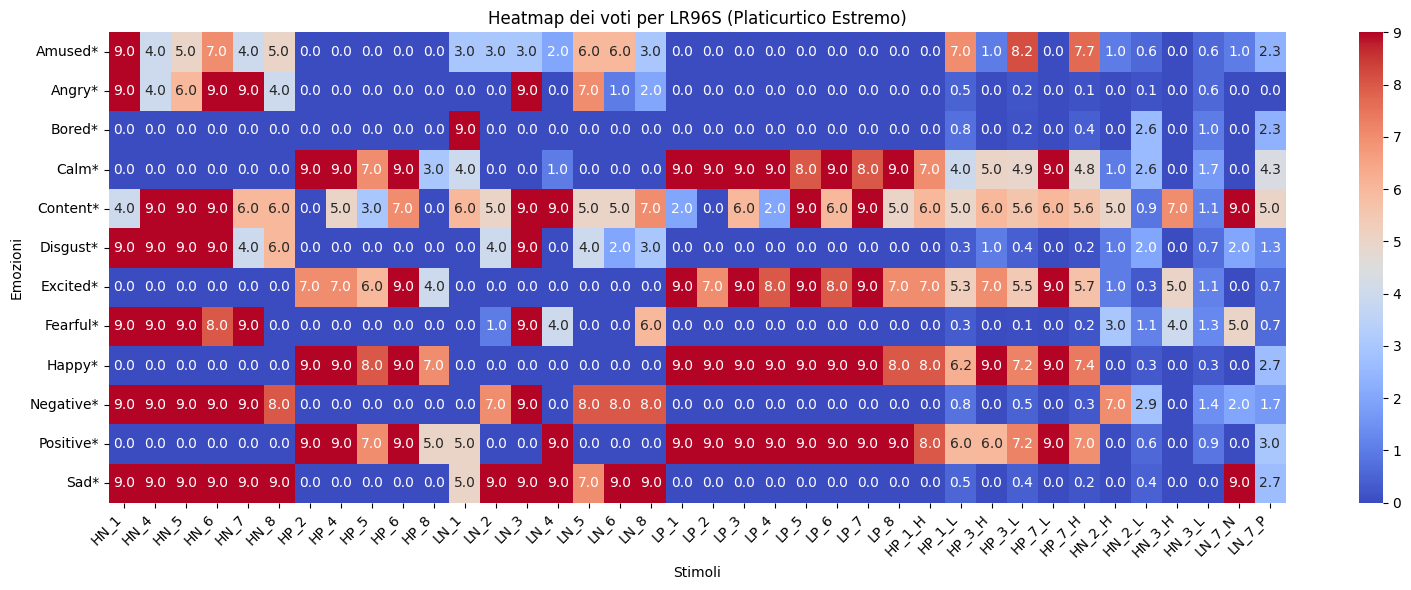

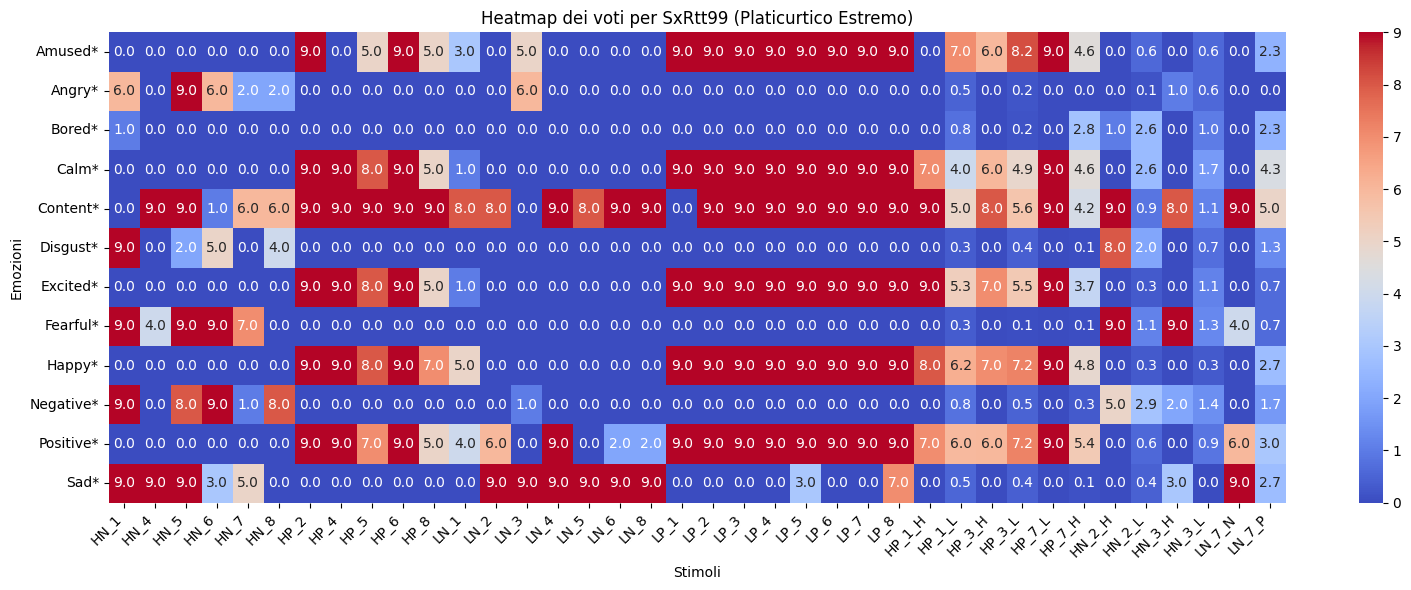

In [39]:
# Plot delle heatmap per gli outliers [LR96S e SxRtt99]
import os
import seaborn as sns

outliers = ['LR96S', 'SxRtt99']
stimuli = [
    "HN_1", "HN_4", "HN_5", "HN_6", "HN_7", "HN_8",
    "HP_2", "HP_4", "HP_5", "HP_6", "HP_8",
    "LN_1", "LN_2", "LN_3", "LN_4", "LN_5", "LN_6", "LN_8",
    "LP_1", "LP_2", "LP_3", "LP_4", "LP_5", "LP_6", "LP_7", "LP_8",
    "HP_1_H", "HP_1_L", "HP_3_H", "HP_3_L", "HP_7_L", "HP_7_H",
    "HN_2_H", "HN_2_L", "HN_3_H", "HN_3_L", "LN_7_N", "LN_7_P"
 ]

data= data[['Participant'] + emotions_to_use+ ["Stimulus_Name"]]

for p in outliers:
    # Seleziona tutte le righe del partecipante e solo le colonne emozioni
    scores_df = data.loc[data['Participant'] == p, emotions_to_use ]

    if scores_df.empty:
        print(f"Nessun dato trovato per il partecipante {p}")
        continue

    # Etichette asse X: usa i nomi degli stimoli se la lunghezza coincide
    n_cols = scores_df.shape[0]
    x_labels = stimuli

    plt.figure(figsize=(16, 6))
    ax = sns.heatmap(
        scores_df.T,
        annot=True,
        fmt='.1f',
        cmap='coolwarm',
        cbar=True,
        xticklabels=x_labels,
        yticklabels=emotions_to_use
    )

    plt.title(f'Heatmap dei voti per {p} (Platicurtico Estremo)')
    plt.xlabel('Stimoli')
    plt.ylabel('Emozioni')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'img/heatmap_{p}.png', bbox_inches='tight', dpi=150)
    plt.show()
    plt.close()

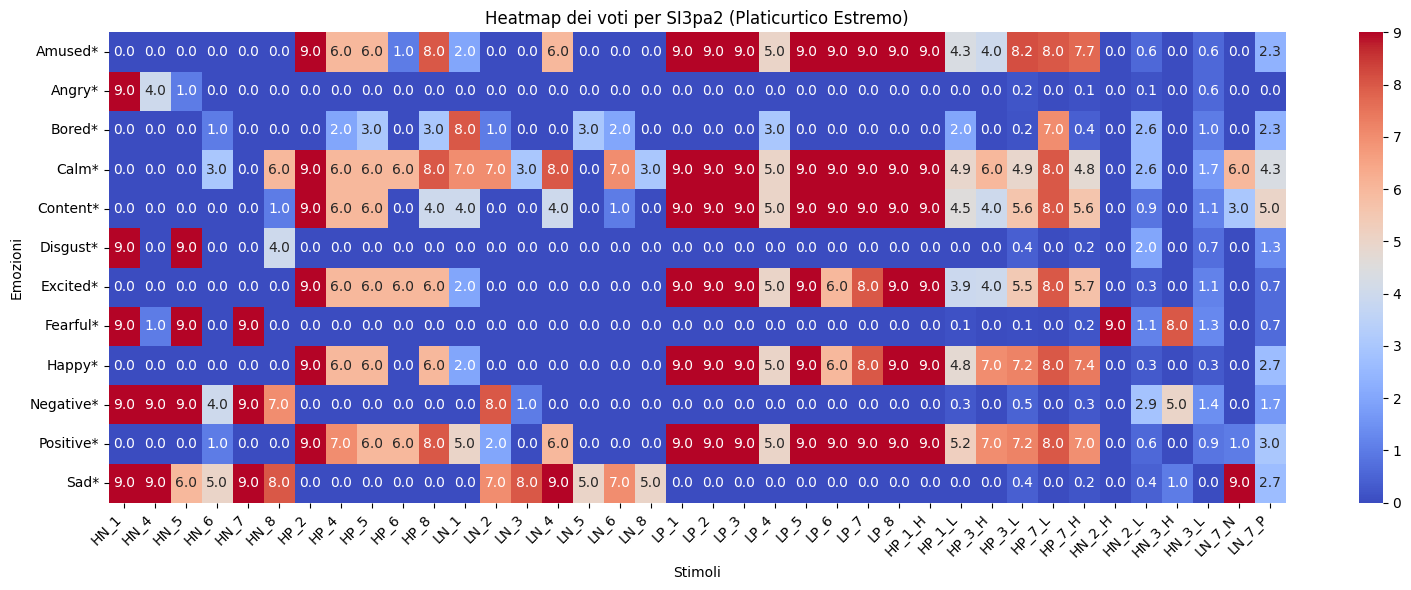

In [41]:
# plot di  SI3pa2 
p = 'SI3pa2'
scores_df = data.loc[data['Participant'] == p, emotions_to_use]

plt.figure(figsize=(16, 6))
ax = sns.heatmap(
    scores_df.T,
    annot=True,
    fmt='.1f',
    cmap='coolwarm',
    cbar=True,
    xticklabels=x_labels,
    yticklabels=emotions_to_use
)

plt.title(f'Heatmap dei voti per {p} (Platicurtico Estremo)')
plt.xlabel('Stimoli')
plt.ylabel('Emozioni')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'img/heatmap_{p}.png', bbox_inches='tight', dpi=150)
plt.show()
plt.close()

In [46]:
csv_file='preprocessed_data_simmetric.csv'

# Assuming df_initial has columns: 'respondent', 'stimulus', and normalized emotion columns
df_for_tensor= pd.read_csv(csv_file)


In [48]:
import numpy as np
import pandas as pd

all_participants = list(df_for_tensor['Participant'].unique())

# --- CONFIGURAZIONE DELLE COPPIE OPPOSTE DI RUSSELL ---
# Sostituisci i numeri con gli indici di colonna corretti delle tue 12 emozioni
# Esempio basato sulla tua heatmap: 
# Amused(0), Angry(1), Bored(2), Calm(3), Content(4), Disgust(5), 
# Excited(6), Fearful(7), Happy(8), Negative(9), Positive(10), Sad(11)
coppie_opposte = [
    (8, 11),  # Happy vs Sad
    (10, 9),  # Positive vs Negative
    (3, 1),   # Calm vs Angry
    (4, 5)    # Content vs Disgust
]

records_screening = []

for p in all_participants:
        # Estrai i voti del partecipante i-esimo (tutti gli stimoli e tutte le emozioni)
    Xi = df_for_tensor[df_for_tensor['Participant'] == p]
    Xi = Xi[emotions_to_use].to_numpy()  # Converti solo le colonne emozioni in un array NumPy 
    
    #print(f"Analizzando partecipante {p} con {Xi.size} voti...")  # Debug: verifica il numero di voti
    
    # 1. Calcolo percentuale di 9
    tot_voti = Xi.size
    num_9 = np.sum(Xi == 9)
    pct_9 = (num_9 / tot_voti) * 100
    
    # 2. Calcolo l'Indice di Contraddizione (ICR)
    # Conta quante volte il partecipante ha dato contemporaneamente voti alti (es. >= 7) 
    # a due emozioni che teoricamente si escludono a vicenda nello stesso stimolo
    contraddizioni = 0
    for emo_A, emo_B in coppie_opposte:
        voti_A = Xi[:, emo_A]
        voti_B = Xi[:, emo_B]
        # Un paradosso si verifica quando entrambi i voti sono alti nello stesso stimolo
        paradosso = np.sum((voti_A >= 7) & (voti_B >= 7))
        contraddizioni += paradosso
        
    records_screening.append({
        'Participant': p,
        'Pct_9': pct_9,
        'Contraddizioni_Russell': contraddizioni
    })

df_screening = pd.DataFrame(records_screening)

# 3. Calcolo gli Z-Score per identificare matematicamente gli outlier rispetto alla popolazione
df_screening['Z_Pct_9'] = (df_screening['Pct_9'] - df_screening['Pct_9'].mean()) / df_screening['Pct_9'].std()
df_screening['Z_Contraddizioni'] = (df_screening['Contraddizioni_Russell'] - df_screening['Contraddizioni_Russell'].mean()) / df_screening['Contraddizioni_Russell'].std()

# --- REGOLE DI ESCLUSIONE MATEMATICA ---
# Un soggetto è un outlier a priori se supera la soglia critica di Z-score (es. 2.0) 
# in uno dei due comportamenti patologici
soglia_critica_z = 2.0

outliers_rilevati = df_screening[
    (df_screening['Z_Pct_9'] > soglia_critica_z) | 
    (df_screening['Z_Contraddizioni'] > soglia_critica_z)
]

print("--- REPORT DI SCREENING AUTOMATICO A PRIORI ---")
if not outliers_rilevati.empty:
    print(f"Rilevati {len(outliers_rilevati)} outlier matematici da escludere:\n")
    print(outliers_rilevati[['Participant', 'Pct_9', 'Z_Pct_9', 'Contraddizioni_Russell', 'Z_Contraddizioni']].to_string(index=False))
else:
    print("Nessun outlier rilevato con i criteri impostati.")

--- REPORT DI SCREENING AUTOMATICO A PRIORI ---
Rilevati 6 outlier matematici da escludere:

Participant     Pct_9   Z_Pct_9  Contraddizioni_Russell  Z_Contraddizioni
    SxRtt99 22.149123  3.270596                       2          2.033042
      yb3T2  3.070175 -0.338451                       2          2.033042
      LR96S 18.201754  2.523897                       4          4.427092
     hMHEK1  8.114035  0.615665                       4          4.427092
      8vDRG 16.885965  2.274997                       0         -0.361008
     Kgh4P3  5.921053  0.200832                       2          2.033042


## Tensore

In [11]:
data_norm

,Participant
0,6k6gw
1,6k6gw
2,6k6gw
3,6k6gw
4,6k6gw
...,...
2389,Hx7dO
2390,Kgh4P3
2391,SI3pa2
2392,V9D5x


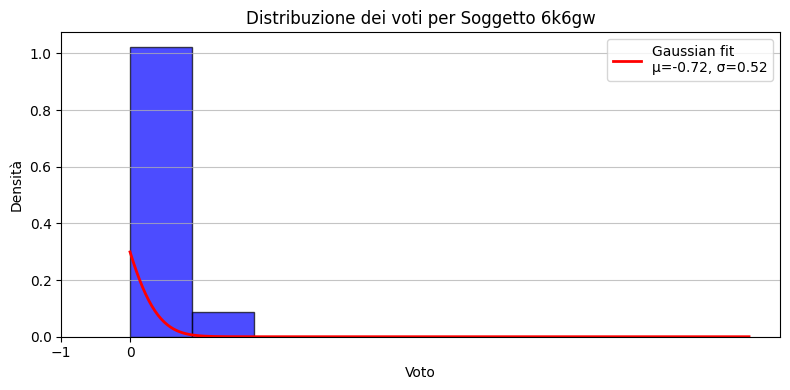

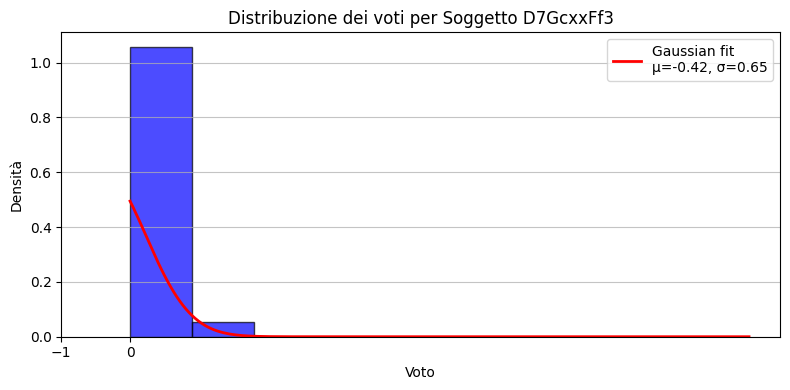

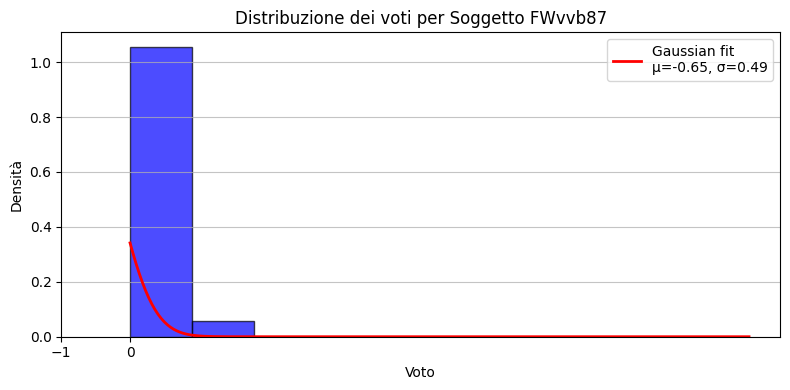

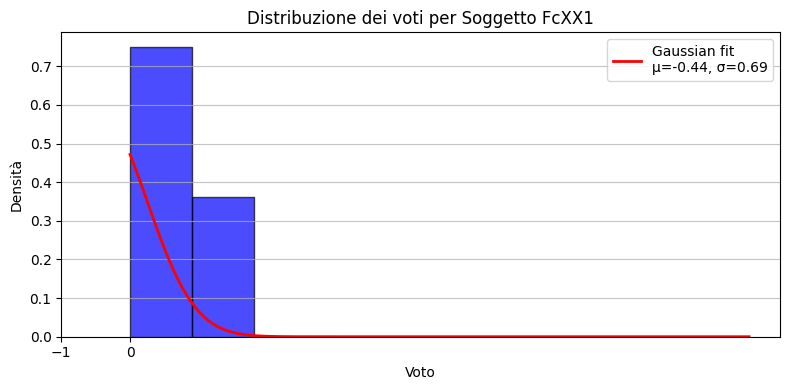

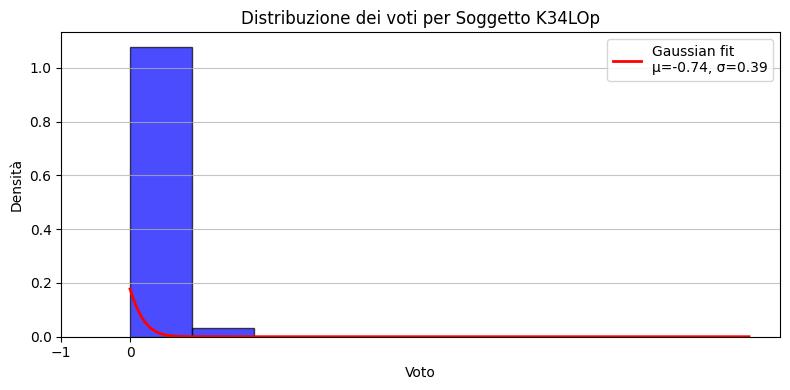

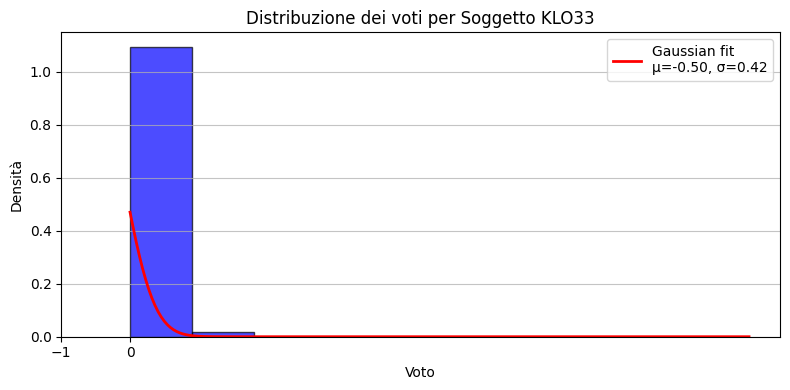

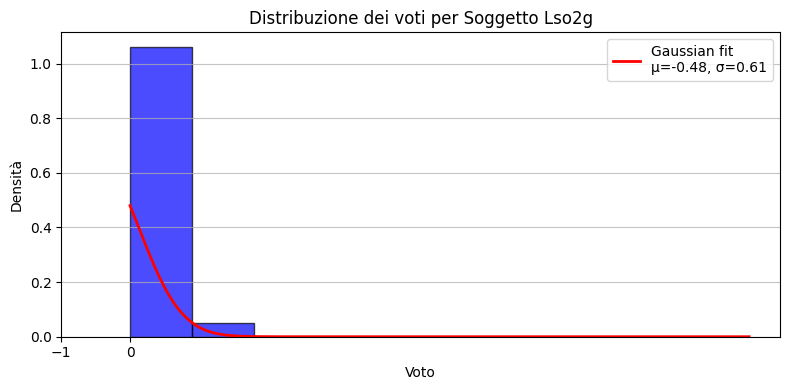

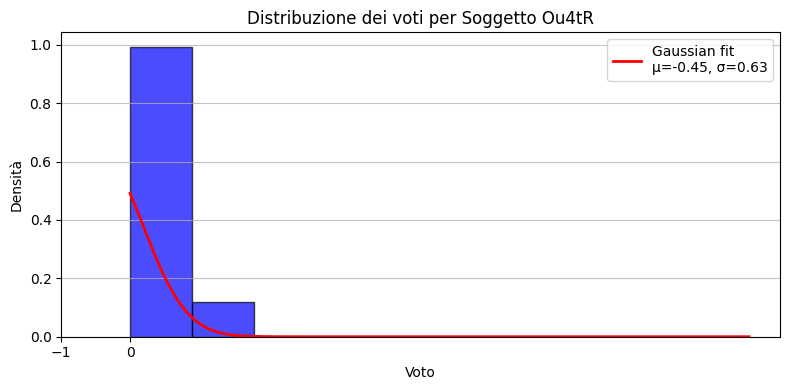

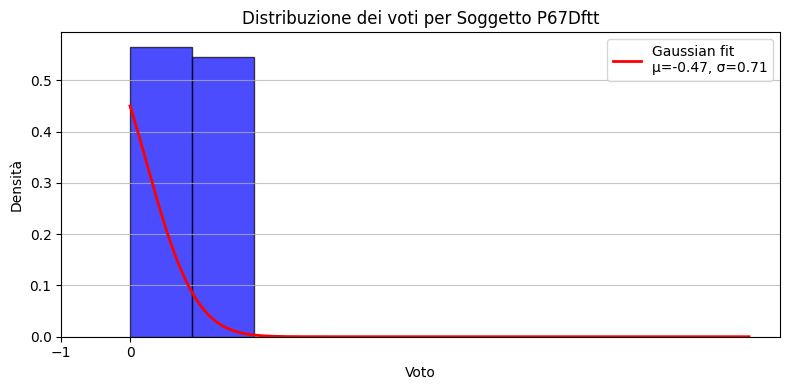

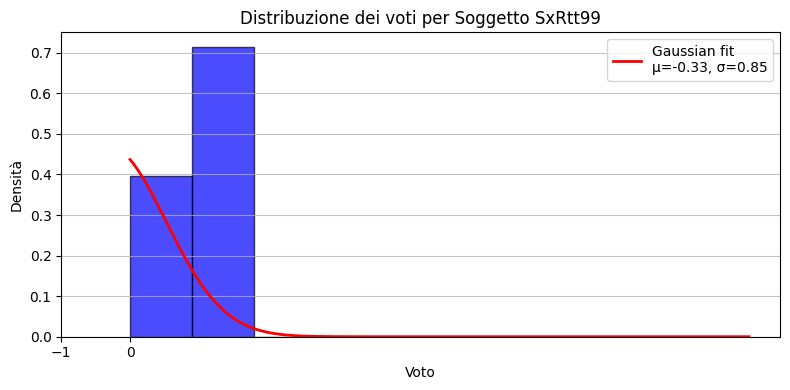

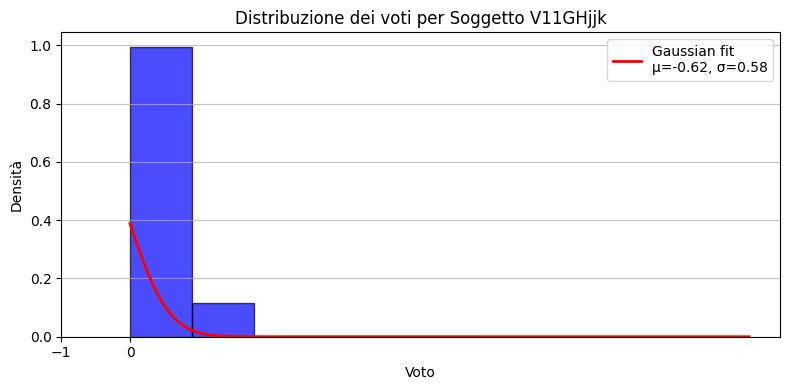

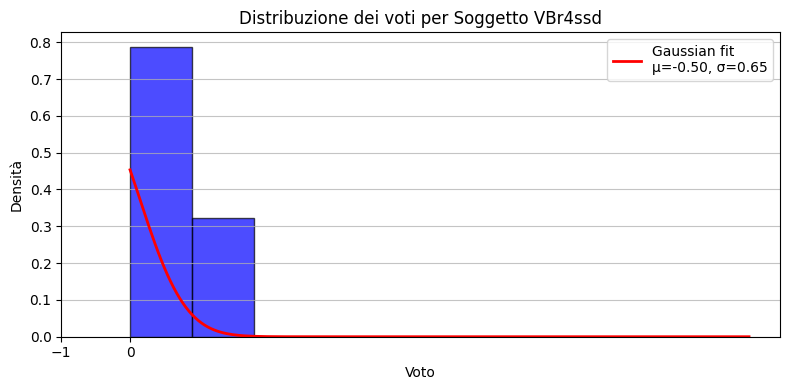

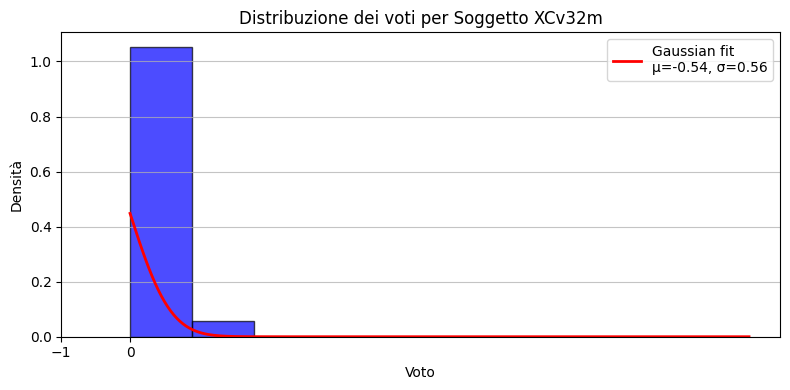

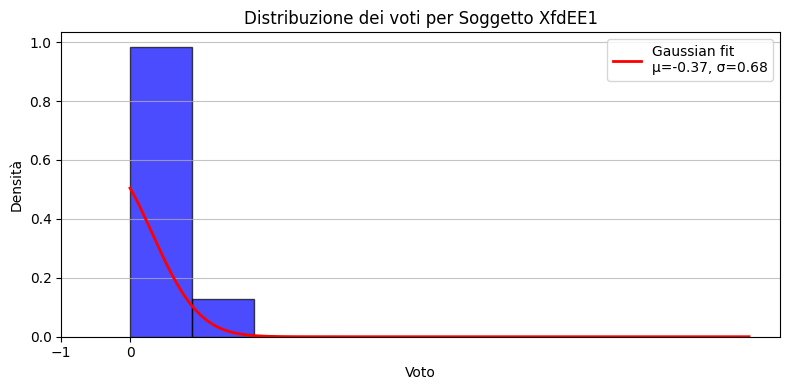

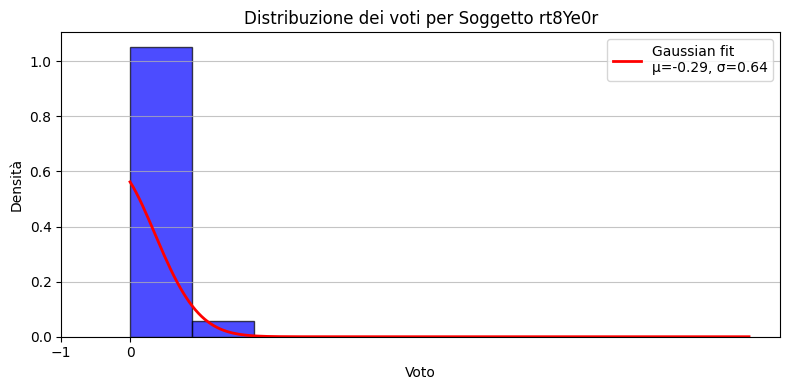

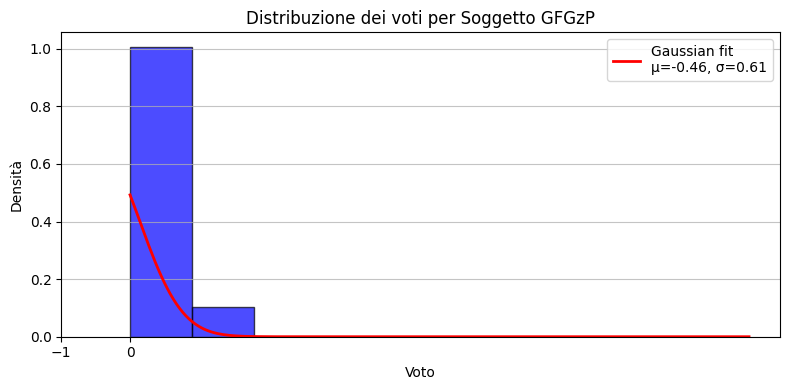

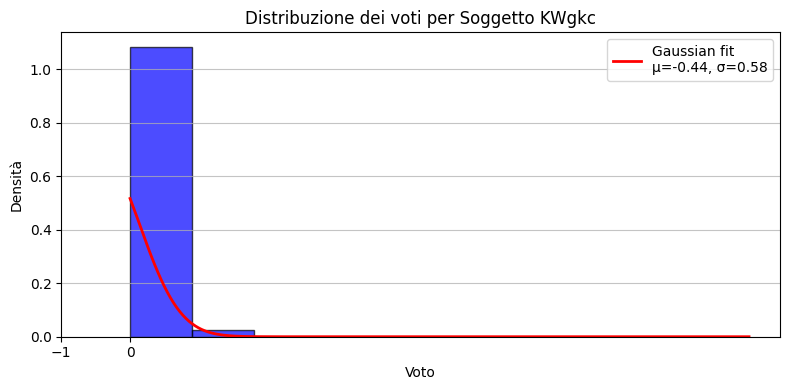

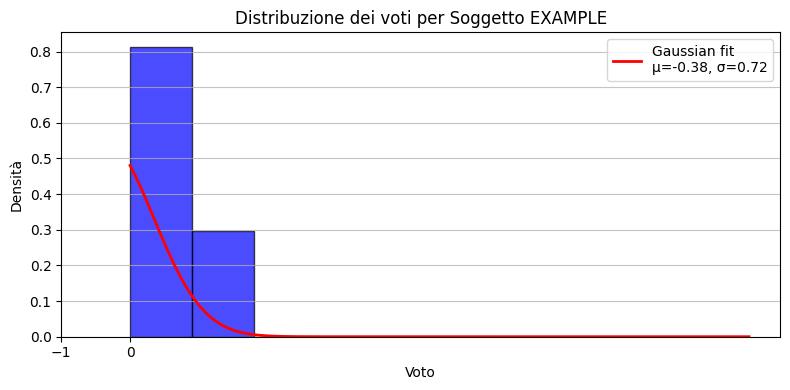

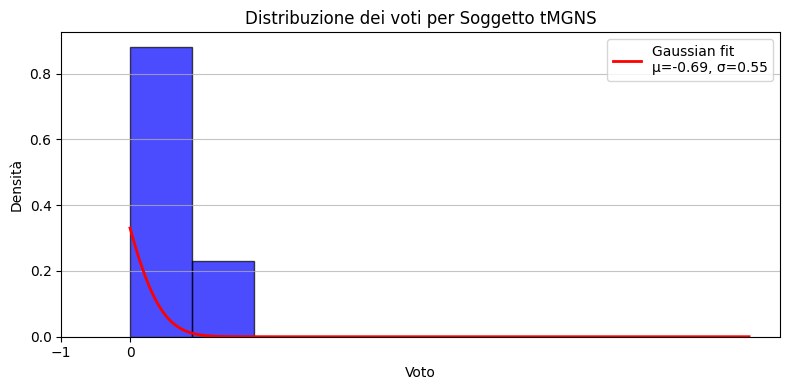

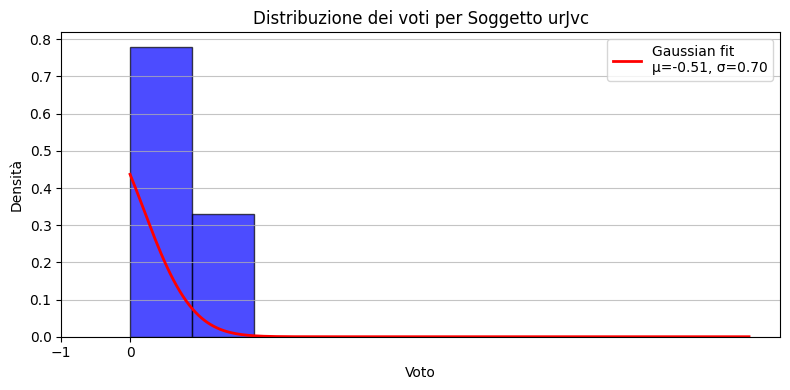

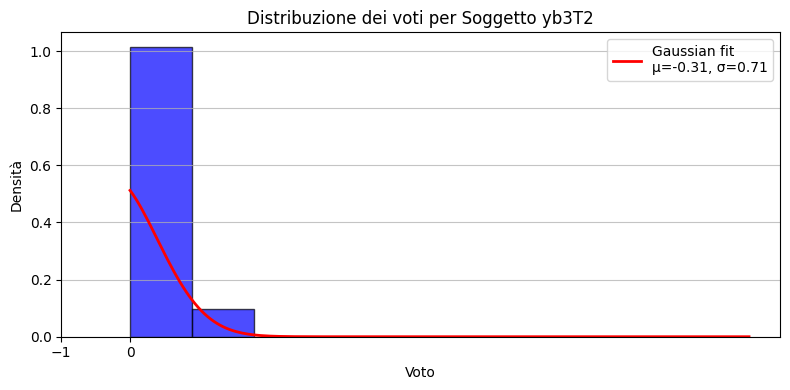

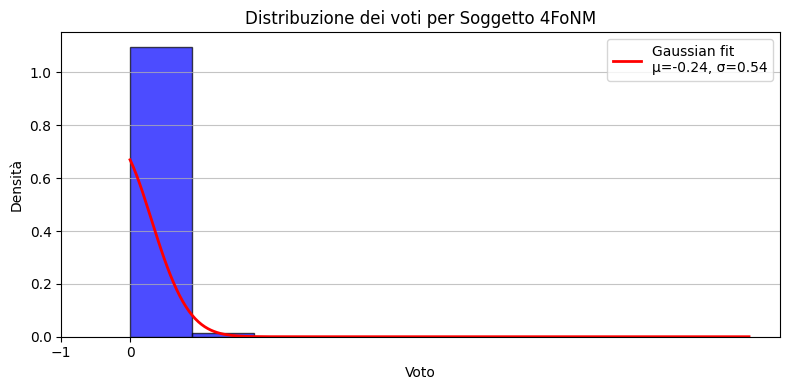

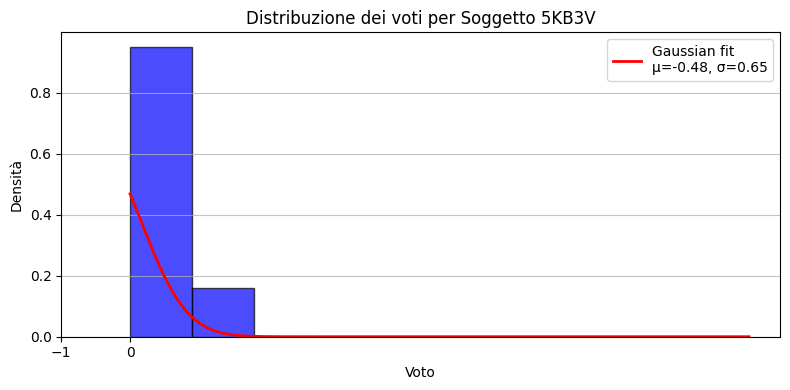

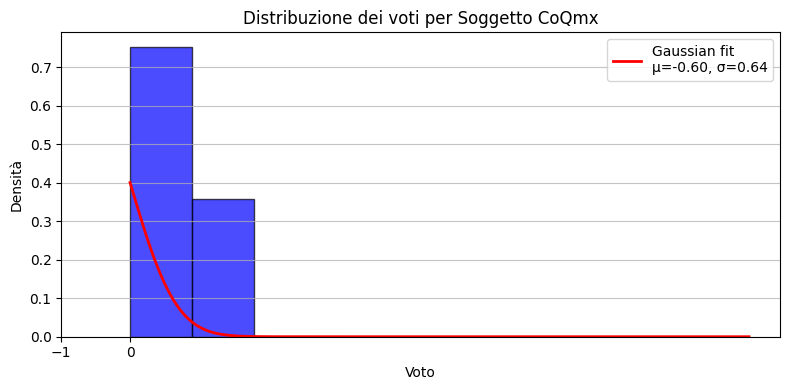

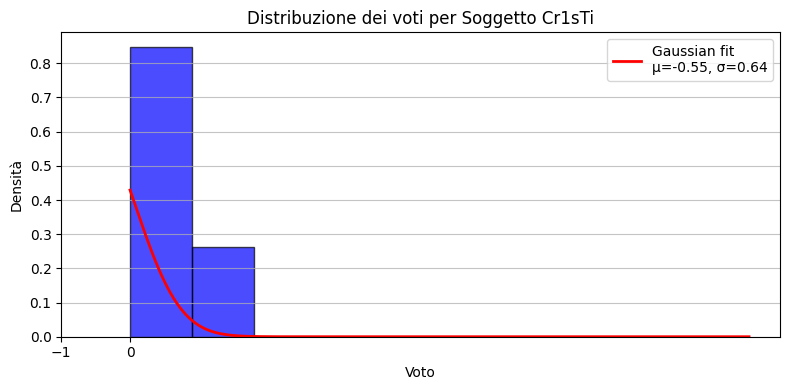

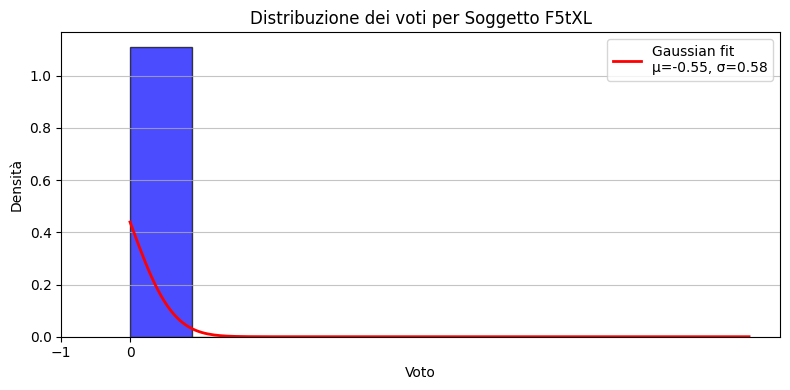

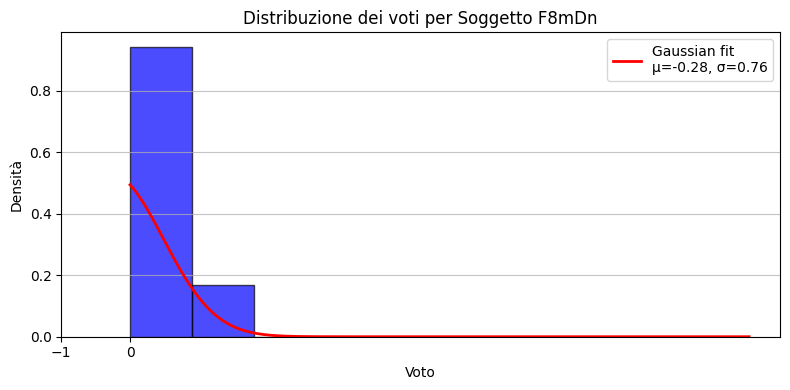

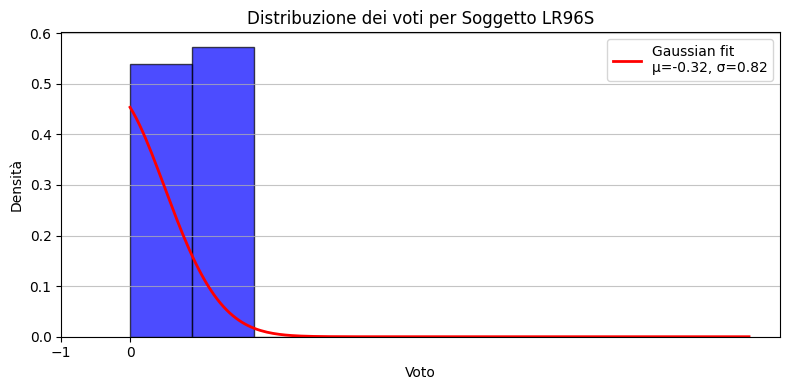

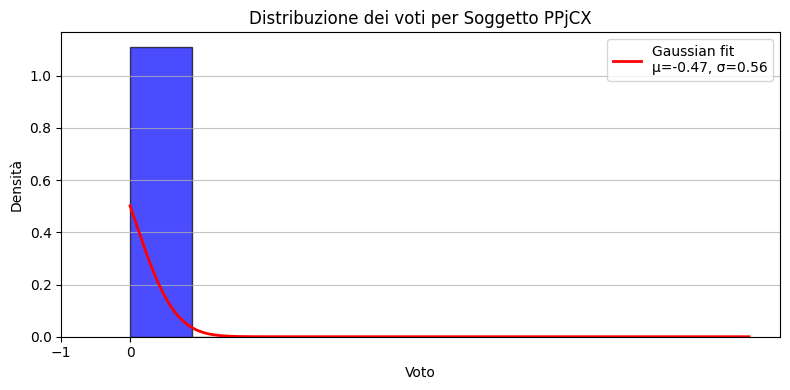

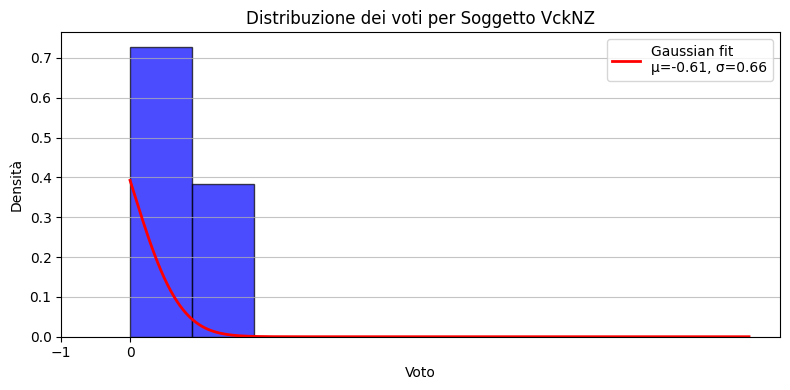

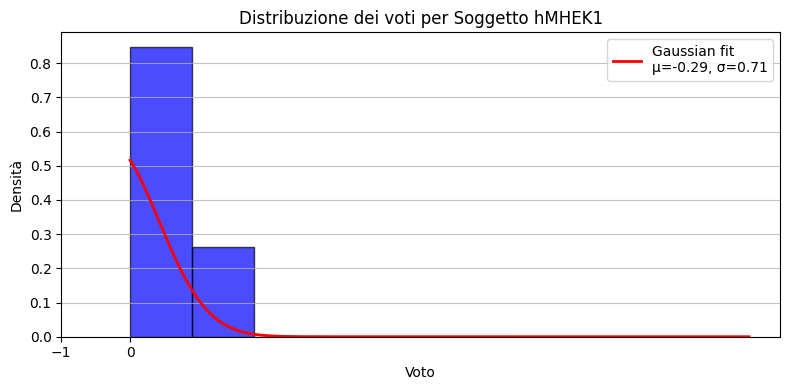

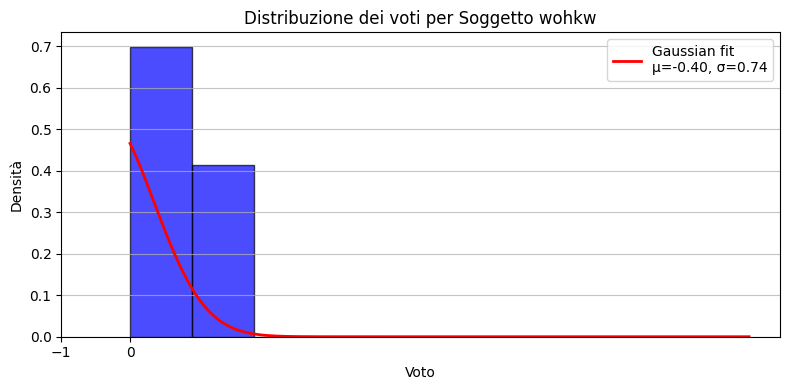

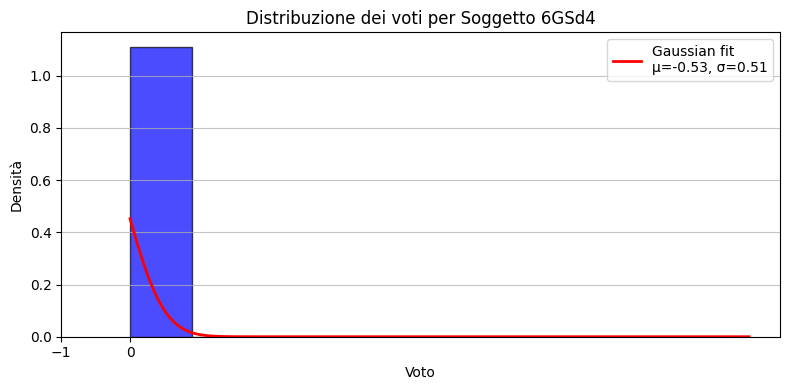

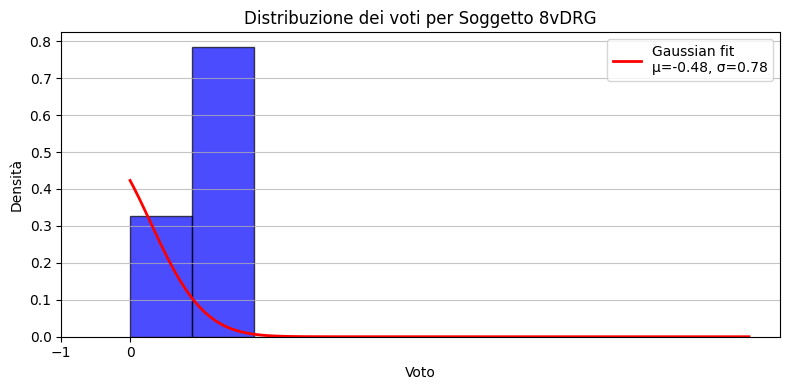

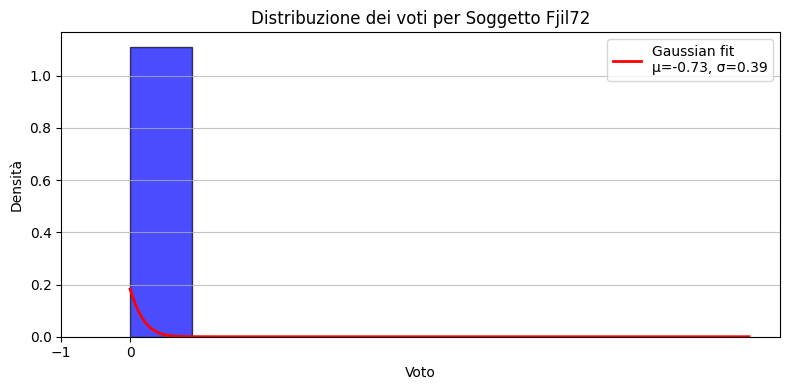

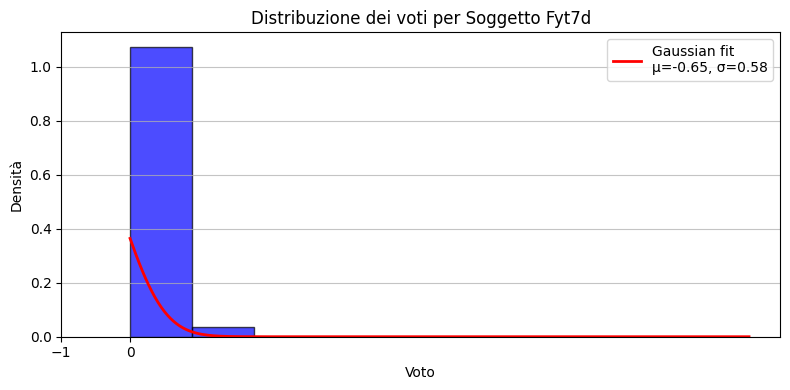

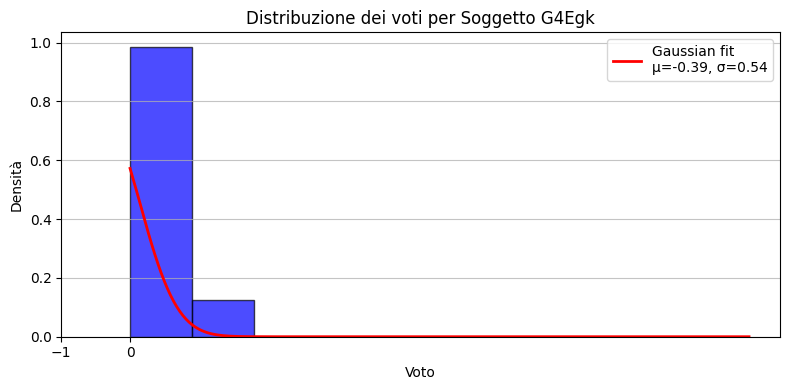

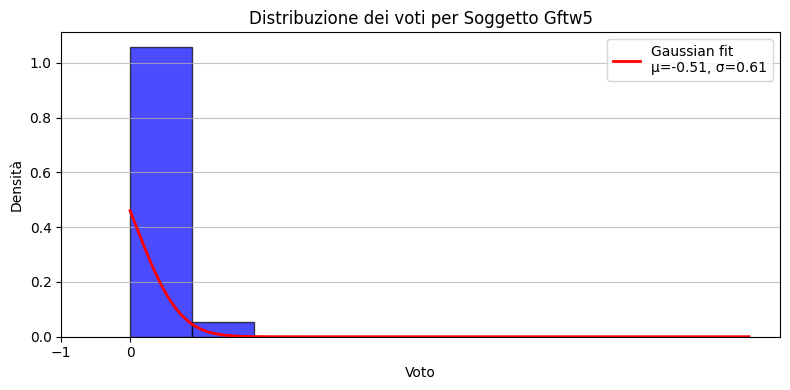

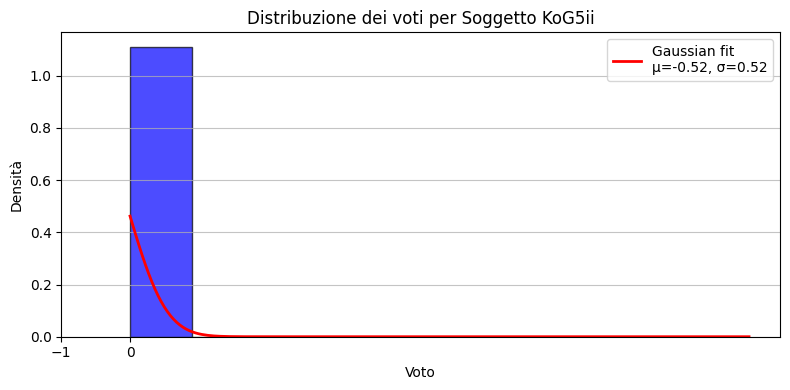

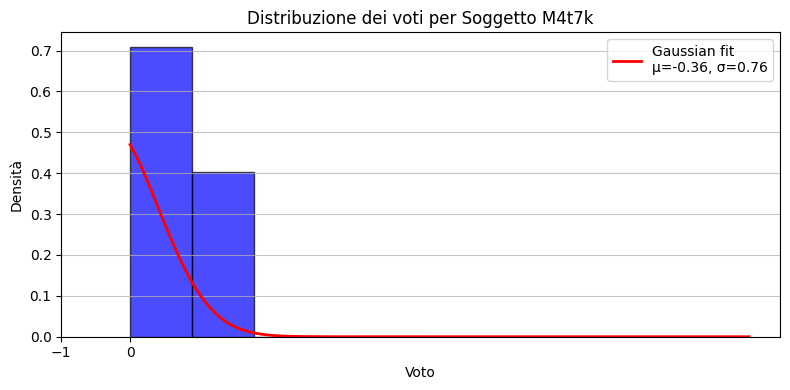

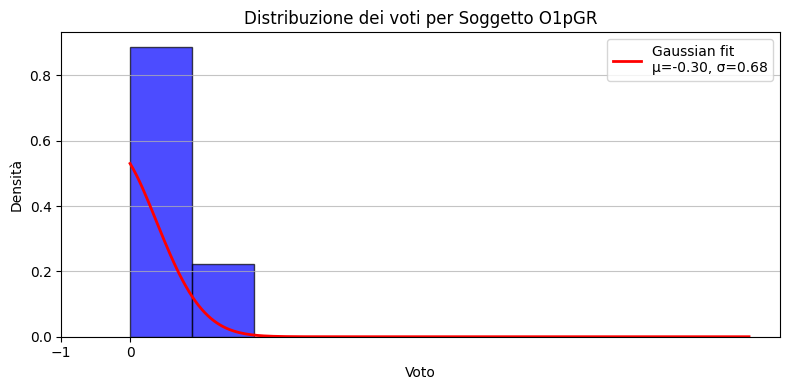

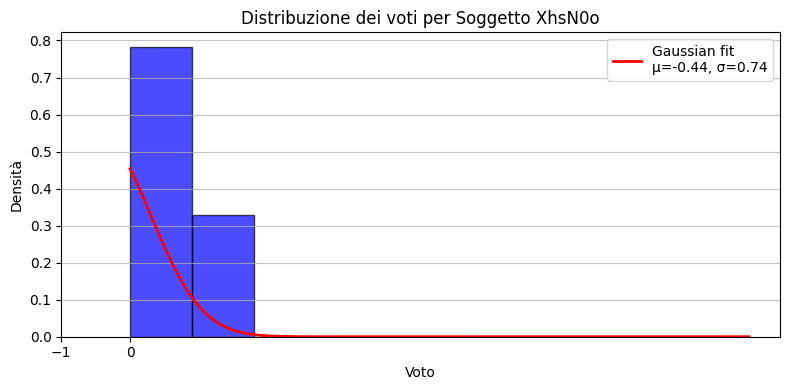

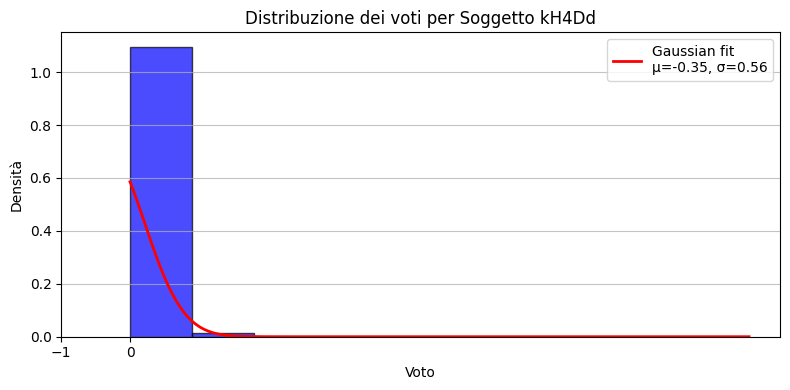

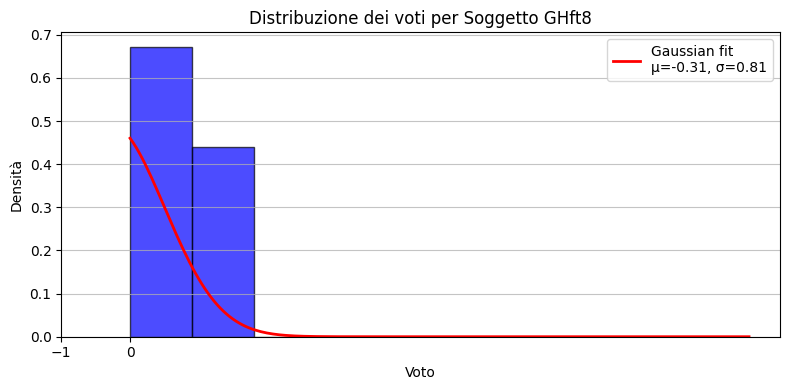

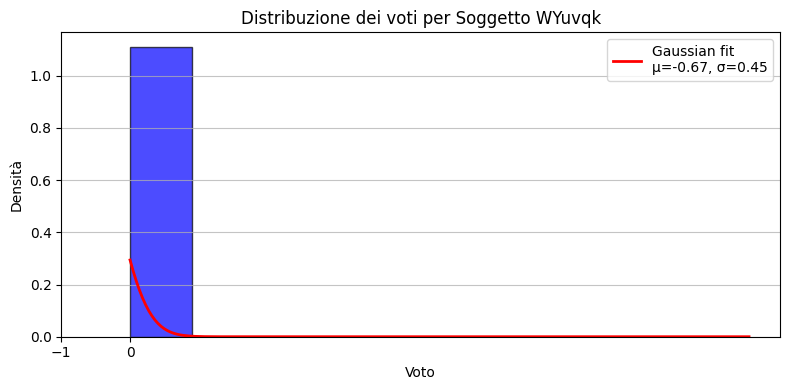

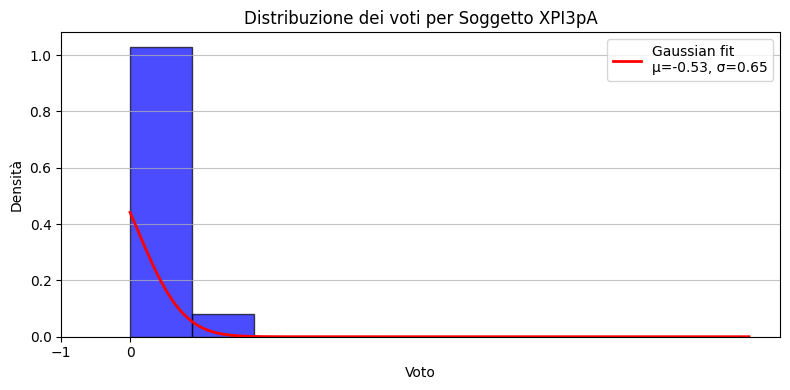

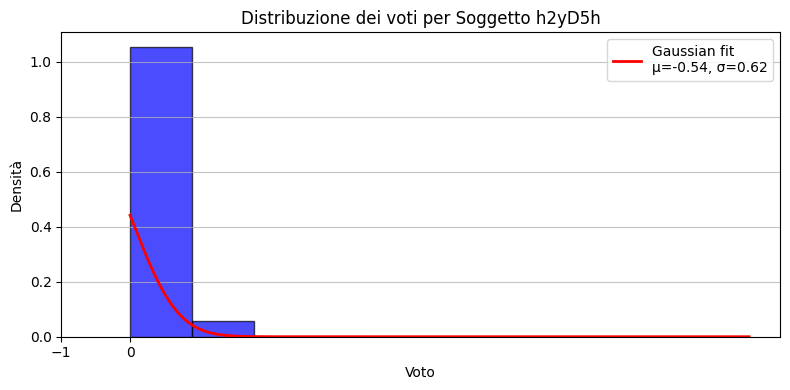

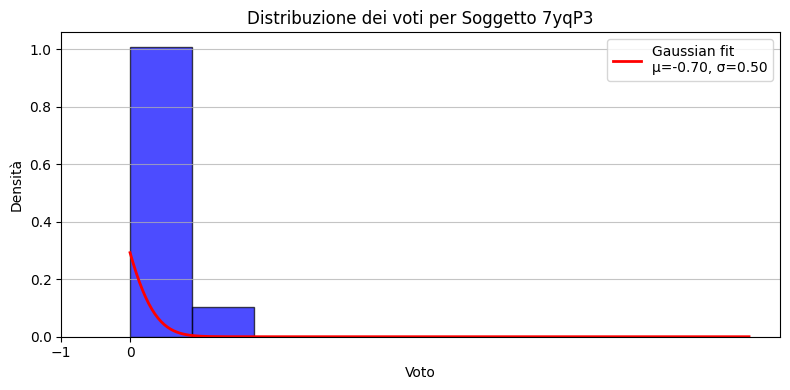

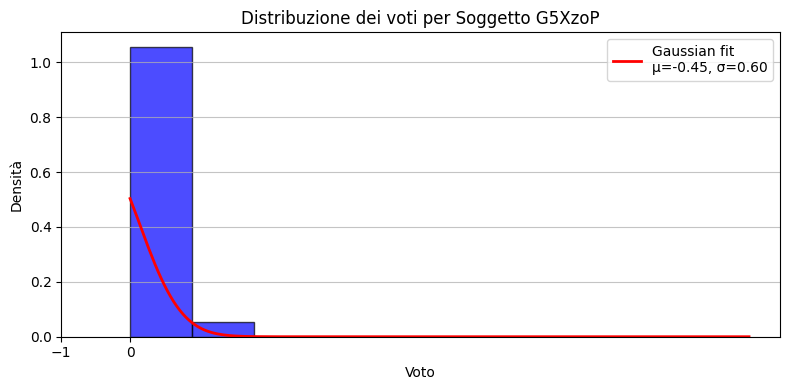

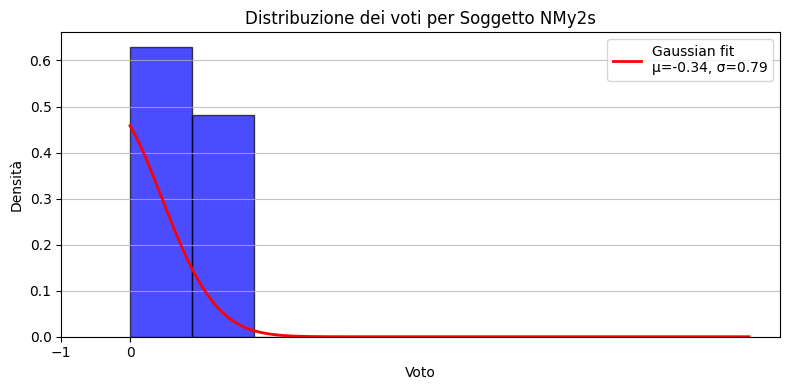

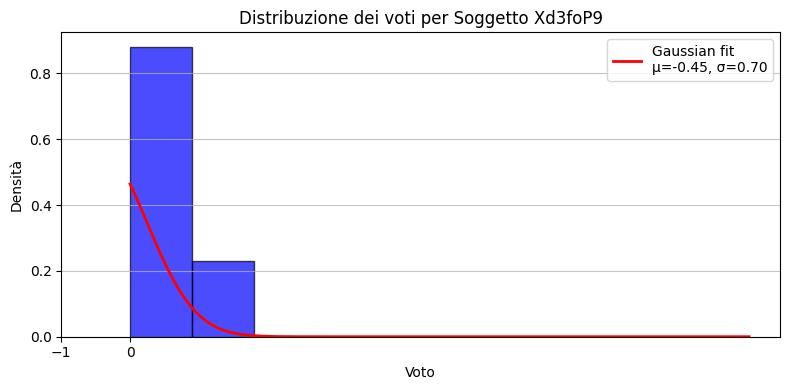

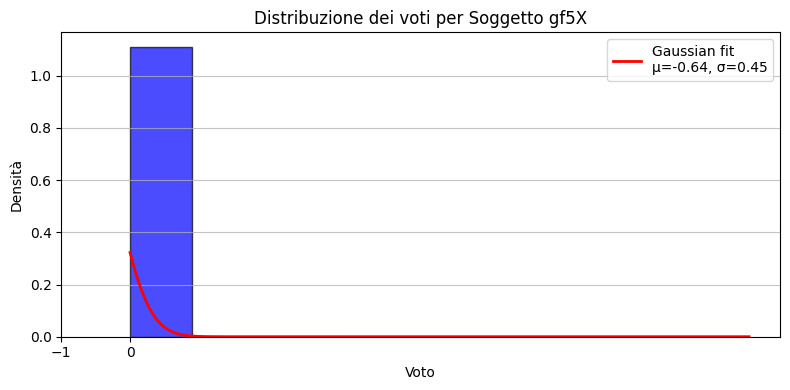

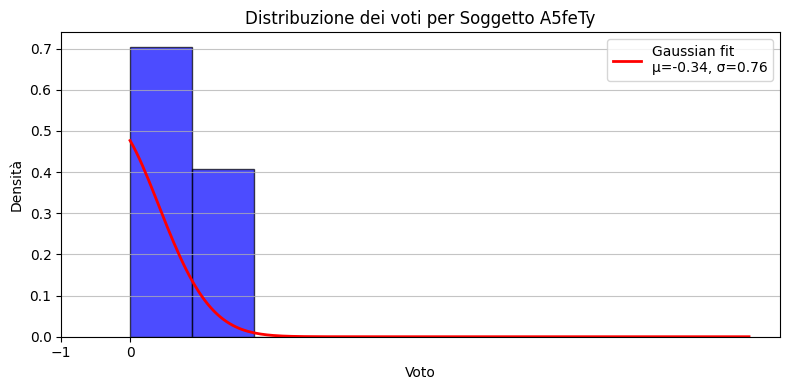

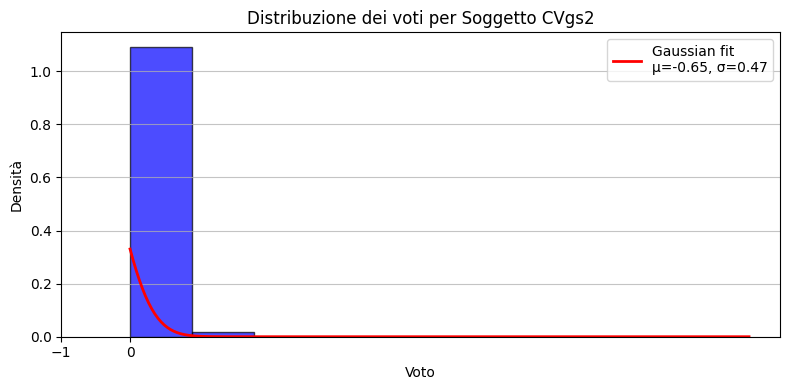

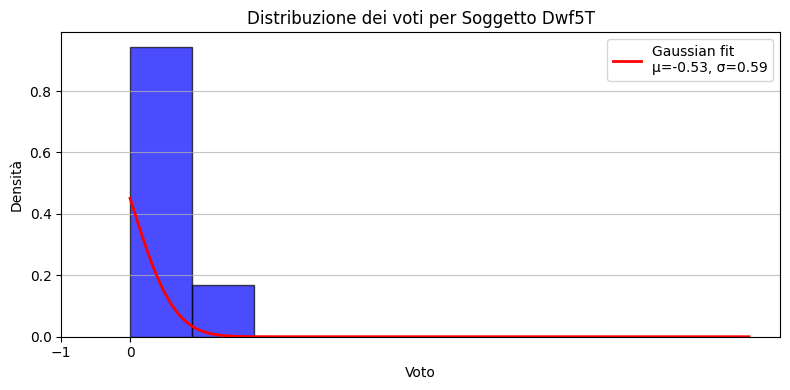

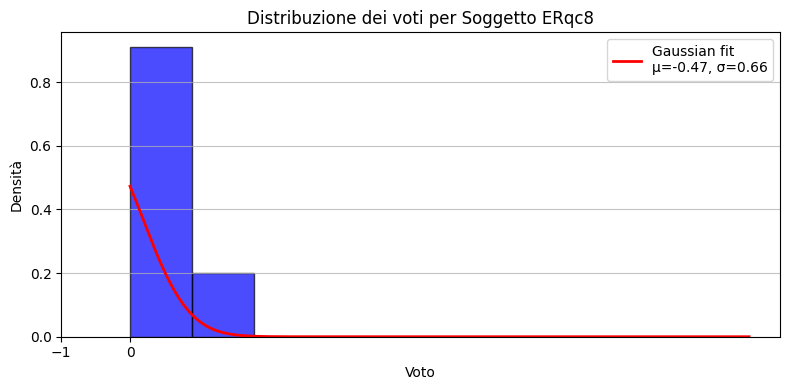

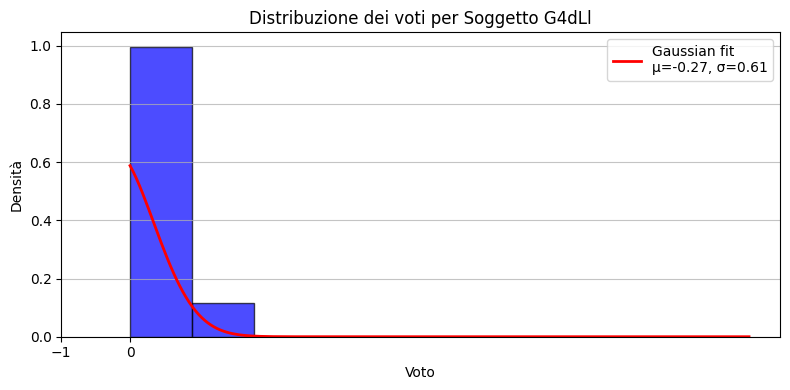

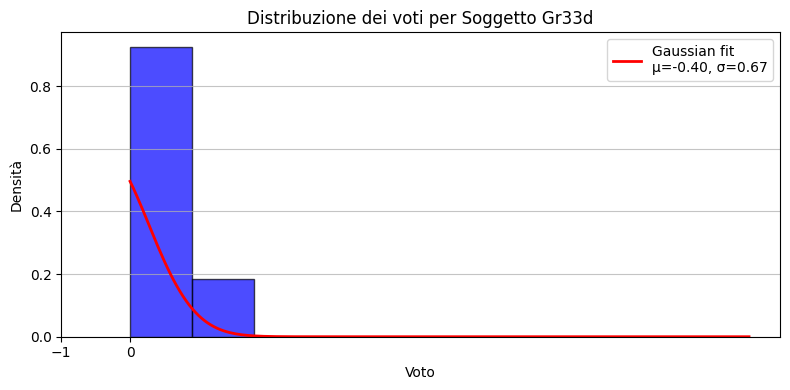

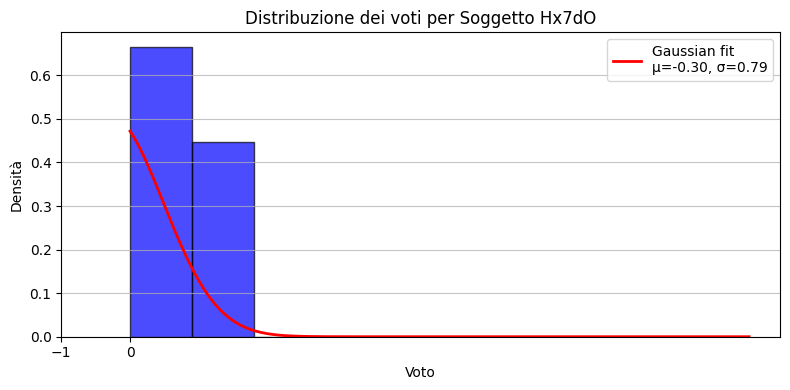

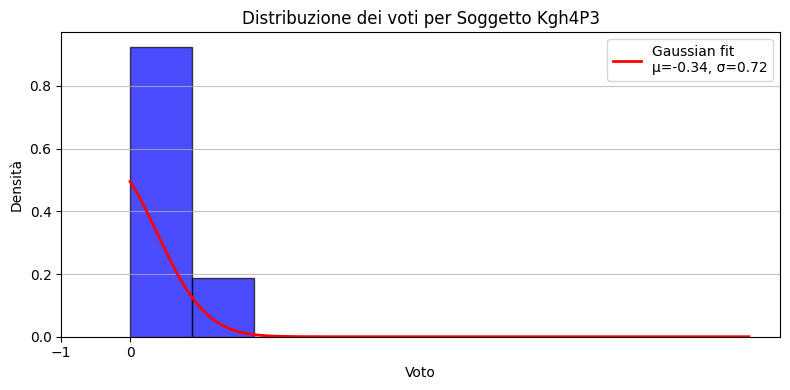

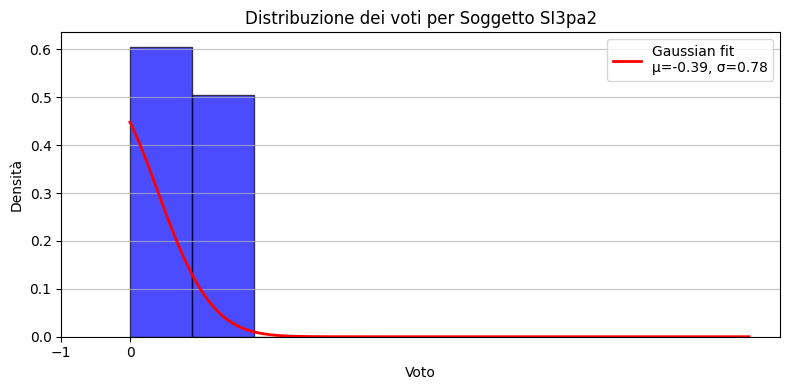

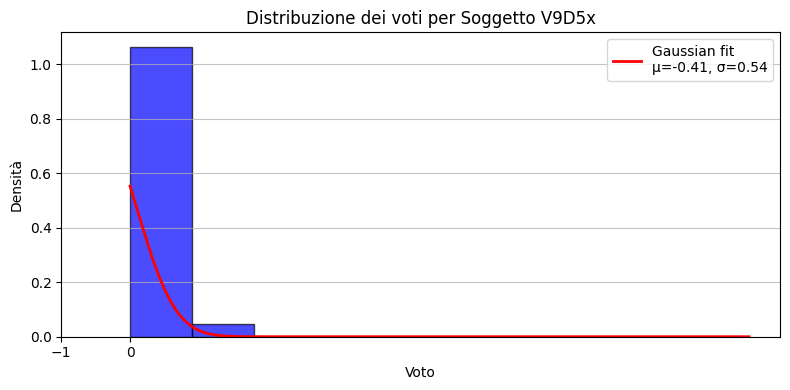

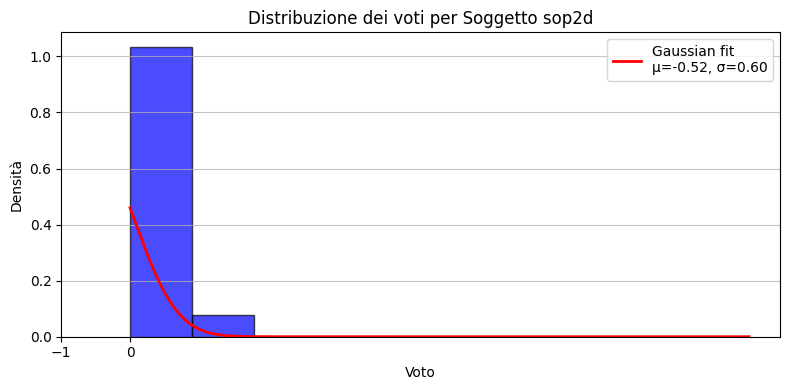

In [ ]:
## ora guardiamo la distribuzione dei voti normalizzati per ogni soggetto (valori continui da -1 a 1)

# utilizziamo le colonne '*_normalized' se presenti nel dataset; mostriamo istogramma + KDE

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Costruisci la lista delle colonne normalizzate e verifica quali sono disponibili
emotions_to_use_normalized = [col + "_normalized" for col in emotions_to_use]
available_cols = [c for c in emotions_to_use_normalized if c in data.columns]
if not available_cols:
    print("Nessuna colonna '*_normalized' trovata nel dataset. Controlla i nomi delle colonne.")
else:
    data_norm = data[['Participant'] + available_cols]

    for participant in data['Participant'].unique():
        # Estrai i voti normalizzati del partecipante e appiattisci
        emotion_df = data_norm.loc[data_norm['Participant'] == participant, available_cols]
        values = emotion_df.to_numpy().ravel()
        values = values[~np.isnan(values)]

        if values.size == 0:
            print(f"{participant}: nessun valore disponibile")
            continue

        mu = values.mean()
        sigma = values.std(ddof=0)

        plt.figure(figsize=(8, 4))
        # Istogramma per dati continui con KDE sovrapposto
        sns.histplot(values, bins=30, kde=True, stat='density', color='skyblue', edgecolor='black', alpha=0.6)

        x = np.linspace(-1, 1, 200)
        # Sovrapponi la gaussiana di riferimento (opzionale) per confronto
        if sigma > 0:
            pdf = norm.pdf(x, mu, sigma)
            plt.plot(x, pdf, 'r-', linewidth=2, label=f'Gaussian fit\nμ={mu:.2f}, σ={sigma:.2f}')
        else:
            plt.axvline(mu, color='r', linestyle='--', label=f'Constant μ={mu:.2f}')

        plt.title(f'Distribuzione normalizzata per Soggetto {participant}')
        plt.xlabel('Score normalizzato')
        plt.ylabel('Densità')
        plt.xlim(-1, 1)
        plt.xticks(np.linspace(-1, 1, 9))
        plt.legend()
        plt.grid(axis='y', alpha=0.75)
        plt.tight_layout()
        import os
        out_dir = 'img/participant_analysis'
        os.makedirs(out_dir, exist_ok=True)
        plt.savefig(os.path.join(out_dir, f'{participant}_normalized_histogram.png'), bbox_inches='tight', dpi=150)
        plt.show()
        plt.close()